In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             fbeta_score, brier_score_loss, confusion_matrix)
from imblearn.ensemble import BalancedRandomForestClassifier
from catboost import CatBoostClassifier
import shap

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel("all_data.xlsx")
df['Quarter'] = pd.to_datetime(df['Quarter'])

In [4]:
split_date = pd.Timestamp('2019-01-01')
train = df[df.Quarter < split_date].copy()
test = df[df.Quarter >= split_date].copy()

print(f"Train: {len(train)} набл., период {train.Quarter.min().strftime('%Y-%m')} — {train.Quarter.max().strftime('%Y-%m')}")
print(f"Test:  {len(test)} набл., период {test.Quarter.min().strftime('%Y-%m')} — {test.Quarter.max().strftime('%Y-%m')}")

Train: 812 набл., период 2011-12 — 2018-12
Test:  379 набл., период 2019-03 — 2025-12


In [5]:
train.BANK_ID.nunique(), train[train['target_8q_window'] == 1].BANK_ID.nunique()

(31, 13)

In [6]:
test.BANK_ID.nunique(), test[test['target_8q_window'] == 1].BANK_ID.nunique()

(18, 5)

In [7]:
train[train['target_8q_window'] == 1].target_8q_window.sum(), test[test['target_8q_window'] == 1].target_8q_window.sum()

(np.int64(98), np.int64(38))

In [8]:
macro_cols = ['rgdp_yoy', 'cpi_y', 'income', 'USD_KZT_qoq']
bank_features = [c for c in df.columns if c not in [
    'BANK_ID', 'Quarter', 'target_8q_window', 'target_4q_window',
    'target_8q_point', 'target_4q_point', 'target', 'Non-interest income', 'Pre-tax net income'] + macro_cols]
all_features = bank_features + macro_cols
target_cols = ['target_8q_window', 'target_4q_window', 'target_8q_point', 'target_4q_point']

In [9]:
print(f"Все фичи ({len(all_features)}): {all_features}")

Все фичи (27): ['Asset_growth', 'Average_risk_weight', 'Capital buffer (CAR)', 'Deposit_growth', 'Demand Deposit Ratio', 'Earning assets to total', 'Liquidity ratio', 'Loan_growth', 'Loans to deposits', 'Trading book assets', 'Equity/Total assets', 'NPL/Total Loans', 'FX Liabilities Share', 'Cash to Assets', 'd_ROA', 'd_ROE', 'd_Net interest margin', 'd_Cost of funds', 'd_Efficiency ratio (version 1)', 'd_Efficiency ratio (version 2)', 'd_Provision Expense Ratio', 'd_Capital buffer (CAR)', 'USD_RUB_qoq', 'rgdp_yoy', 'cpi_y', 'income', 'USD_KZT_qoq']


In [10]:
crisis_test = sorted(test[test.target_8q_window == 1].BANK_ID.unique())
for bid in crisis_test:
    tr_c = int(train[train.BANK_ID == bid]['target_8q_window'].sum()) if bid in train.BANK_ID.values else 0
    te_c = int(test[test.BANK_ID == bid]['target_8q_window'].sum())
    status = "НОВЫЙ" if tr_c == 0 else f"разделён ({tr_c}+{te_c})"
    print(f"  BANK_ID={bid}: [{status}]")

  BANK_ID=4: [НОВЫЙ]
  BANK_ID=6: [НОВЫЙ]
  BANK_ID=15: [разделён (2+6)]
  BANK_ID=23: [НОВЫЙ]
  BANK_ID=44: [НОВЫЙ]


In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(train_df, features, threshold=5):
    """Итеративное удаление переменных по VIF"""
    scaler = StandardScaler()
    current = list(features)
    removed = []
    while True:
        X = scaler.fit_transform(train_df[current])
        vifs = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
        idx = np.argmax(vifs)
        if vifs[idx] < threshold:
            break
        removed.append((current[idx], round(vifs[idx], 1)))
        print(f"  Удаляем: {current[idx]} (VIF={vifs[idx]:.1f})")
        current.remove(current[idx])
    return current, removed

In [12]:
def evaluate(y_true, y_prob):
    """Оценка модели: оптимизация порога по F2, расчёт метрик"""
    best_f2, best_thresh = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.01):
        yp = (y_prob >= t).astype(int)
        if yp.sum() == 0:
            continue
        f2 = fbeta_score(y_true, yp, beta=2, zero_division=0)
        if f2 > best_f2:
            best_f2 = f2
            best_thresh = round(t, 2)
    y_pred = (y_prob >= best_thresh).astype(int)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    cm = confusion_matrix(y_true, y_pred)
    return {
        'AUC': round(auc, 3) if auc else None,
        'F2': round(best_f2, 3),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 3),
        'Brier': round(brier_score_loss(y_true, y_prob), 3),
        'Threshold': best_thresh,
        'TN': int(cm[0,0]), 'FP': int(cm[0,1]), 'FN': int(cm[1,0]), 'TP': int(cm[1,1])}

In [13]:
def print_results(name, results):
    for target, res in results.items():
        print(f"  {target:25} AUC={res['AUC']}  F2={res['F2']}  Prec={res['Precision']}  "
              f"Rec={res['Recall']}  Brier={res['Brier']}  Thresh={res['Threshold']}  "
              f"TN={res['TN']} FP={res['FP']} FN={res['FN']} TP={res['TP']}")

# 1) Logit

In [14]:
logit_features, removed = calc_vif(train, all_features, threshold=5)

  Удаляем: Equity/Total assets (VIF=10.8)
  Удаляем: Cash to Assets (VIF=7.0)
  Удаляем: rgdp_yoy (VIF=5.6)
  Удаляем: Asset_growth (VIF=5.2)


In [15]:
print(f"Удалено: {len(removed)}, осталось: {len(logit_features)} фичей")

Удалено: 4, осталось: 23 фичей


In [16]:
scaler = StandardScaler()
X_train_l = scaler.fit_transform(train[logit_features])
X_test_l = scaler.transform(test[logit_features])

logit_results = {}
logit_coefs = {}

for target in target_cols:
    model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1877) 
    model.fit(X_train_l, train[target].values)
    logit_results[target] = evaluate(test[target].values, model.predict_proba(X_test_l)[:, 1])
    coef = pd.DataFrame({'feature': logit_features, 'coef': model.coef_[0]})
    coef = coef.sort_values('coef', key=abs, ascending=False)
    logit_coefs[target] = coef

print("\nРезультаты:")
print_results("Logit", logit_results)


Результаты:
  target_8q_window          AUC=0.772  F2=0.453  Prec=0.185  Rec=0.711  Brier=0.104  Thresh=0.05  TN=222 FP=119 FN=11 TP=27
  target_4q_window          AUC=0.83  F2=0.414  Prec=0.185  Rec=0.6  Brier=0.045  Thresh=0.05  TN=306 FP=53 FN=8 TP=12
  target_8q_point           AUC=0.691  F2=0.118  Prec=0.027  Rec=0.75  Brier=0.11  Thresh=0.05  TN=267 FP=108 FN=1 TP=3
  target_4q_point           AUC=0.59  F2=0.135  Prec=0.059  Rec=0.2  Brier=0.036  Thresh=0.33  TN=358 FP=16 FN=4 TP=1


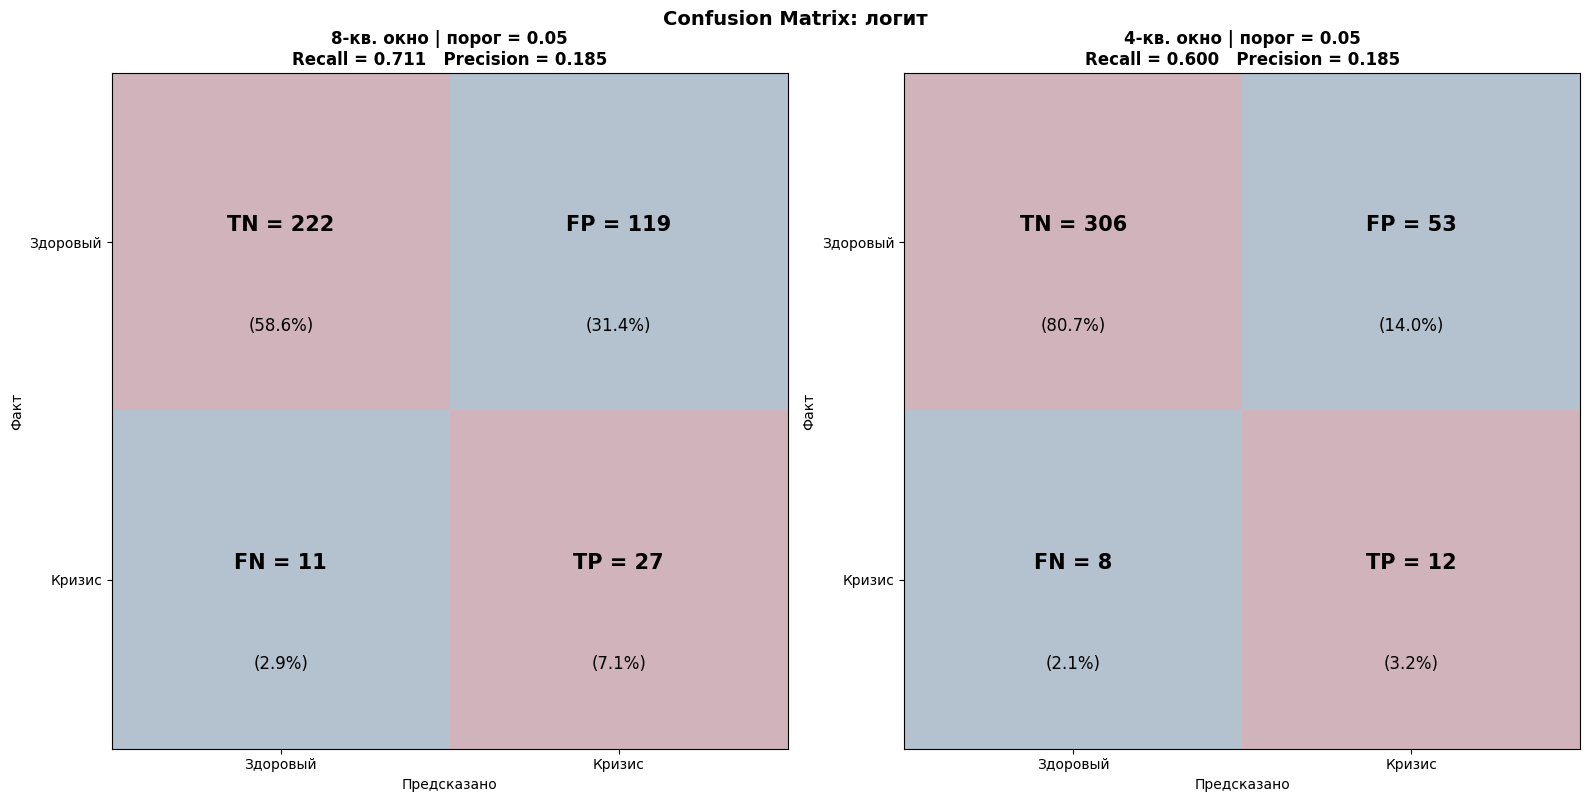

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
labels = ['8-кв. окно', '4-кв. окно'] # , '8-кв. точка', '4-кв. точка'

cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for ax, target, label in zip(axes.flatten(), target_cols, labels):
    r = logit_results[target]
    cm = np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])

    prec = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    rec = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0

    ax.imshow([[0, 1], [1, 0]], cmap='RdBu', alpha=0.3, extent=[0, 2, 0, 2])
    for row in range(2):
        for col in range(2):
            val = cm[row, col]
            pct = val / cm.sum() * 100
            ax.text(col + 0.5, 1.55 - row, f'{cell_labels[row][col]} = {val}',
                    ha='center', va='center', fontsize=15, fontweight='bold')
            ax.text(col + 0.5, 1.25 - row, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=12)

    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Здоровый', 'Кризис'])
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['Кризис', 'Здоровый'])
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Факт')
    ax.set_title(f'{label} | порог = {r["Threshold"]}\n'
                 f'Recall = {rec:.3f}   Precision = {prec:.3f}', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrix: логит', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('logit_confusion_matrices.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

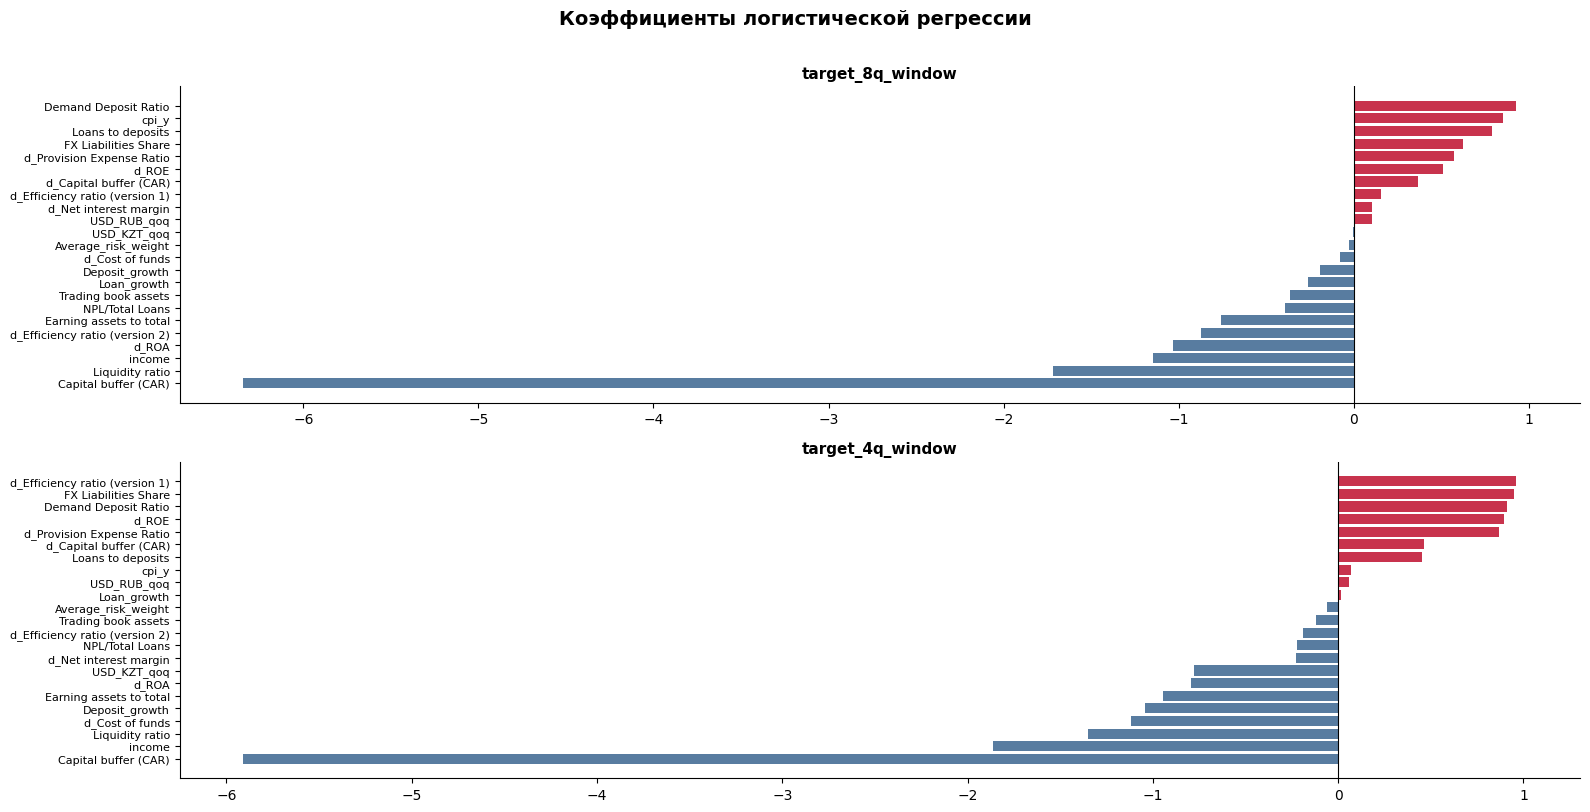

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
axes = axes.flatten()

for i, target in enumerate(['target_8q_window', 'target_4q_window']):
    ax = axes[i]
    coef_sorted = logit_coefs[target].sort_values('coef')
    colors = ['#BB0021' if c > 0 else '#2E5B88' for c in coef_sorted['coef']]
    ax.barh(range(len(coef_sorted)), coef_sorted['coef'], color=colors, alpha=0.8)
    ax.set_yticks(range(len(coef_sorted)))
    ax.set_yticklabels(coef_sorted['feature'], fontsize=8)
    ax.set_title(target, fontweight='bold', fontsize=11)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Коэффициенты логистической регрессии', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('logit_coef_grid.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [19]:
# # === Логит без контринтуитивных переменных ===
# counter_intuitive = ['d_Efficiency ratio (version 2)',
#                      'Capital buffer (CAR)', 'd_ROE', 'NPL/Total Loans']
# logit_features_clean = [f for f in logit_features if f not in counter_intuitive]

# scaler_clean = StandardScaler()
# X_train_cl = scaler_clean.fit_transform(train[logit_features_clean])
# X_test_cl = scaler_clean.transform(test[logit_features_clean])

# logit_results_clean = {}
# logit_coefs_clean = {}

# for target in target_cols:
#     model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1877)
#     model.fit(X_train_cl, train[target].values)
#     logit_results_clean[target] = evaluate(test[target].values, model.predict_proba(X_test_cl)[:, 1])
#     coef = pd.DataFrame({'feature': logit_features_clean, 'coef': model.coef_[0]})
#     coef = coef.sort_values('coef', key=abs, ascending=False)
#     logit_coefs_clean[target] = coef

# print("\nРезультаты (без контринтуитивных, 20 фичей):")
# print_results("Logit clean", logit_results_clean)

In [20]:
# fig, axes = plt.subplots(2, 2, figsize=(16, 8))
# labels = ['8-кв. окно', '4-кв. окно', '8-кв. точка', '4-кв. точка']

# cell_labels = [['TN', 'FP'], ['FN', 'TP']]

# for ax, target, label in zip(axes.flatten(), target_cols, labels):
#     r = logit_results_clean[target]
#     cm = np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])
#     tpr = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0
#     fpr = cm[0,1] / (cm[0,1] + cm[0,0]) if (cm[0,1] + cm[0,0]) > 0 else 0

#     ax.imshow([[0, 1], [1, 0]], cmap='RdBu', alpha=0.3, extent=[0, 2, 0, 2])
#     for row in range(2):
#         for col in range(2):
#             val = cm[row, col]
#             pct = val / cm.sum() * 100
#             ax.text(col + 0.5, 1.55 - row, f'{cell_labels[row][col]} = {val}',
#                     ha='center', va='center', fontsize=15, fontweight='bold')
#             ax.text(col + 0.5, 1.25 - row, f'({pct:.1f}%)',
#                     ha='center', va='center', fontsize=12)

#     ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Здоровый', 'Кризис'])
#     ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['Кризис', 'Здоровый'])
#     ax.set_xlabel('Предсказано'); ax.set_ylabel('Факт')
#     ax.set_title(f'{label} | порог = {r["Threshold"]}\n'
#                  f'Recall = {tpr:.3f}   Precision = {fpr:.3f}', fontweight='bold', fontsize=12)

# plt.suptitle('Confusion Matrix: логит очищенный', fontsize=14, fontweight='bold')
# plt.tight_layout()
# # plt.savefig('logit_confusion_matrices.png', dpi=200, bbox_inches='tight', facecolor='white')
# plt.show()

In [21]:
# fig, axes = plt.subplots(2, 2, figsize=(20, 14))
# axes = axes.flatten()

# for i, target in enumerate(logit_coefs_clean):
#     ax = axes[i]
#     coef_sorted = logit_coefs_clean[target].sort_values('coef')
#     colors = ['#BB0021' if c > 0 else '#2E5B88' for c in coef_sorted['coef']]
#     ax.barh(range(len(coef_sorted)), coef_sorted['coef'], color=colors, alpha=0.8)
#     ax.set_yticks(range(len(coef_sorted)))
#     ax.set_yticklabels(coef_sorted['feature'], fontsize=8)
#     ax.set_title(target, fontweight='bold', fontsize=11)
#     ax.axvline(x=0, color='black', linewidth=0.8)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

# fig.suptitle('Коэффициенты очищенной логистической регрессии', fontsize=14, fontweight='bold', y=1.01)
# plt.tight_layout()
# # plt.savefig('logit_coef_grid.png', dpi=200, bbox_inches='tight', facecolor='white')
# plt.show()

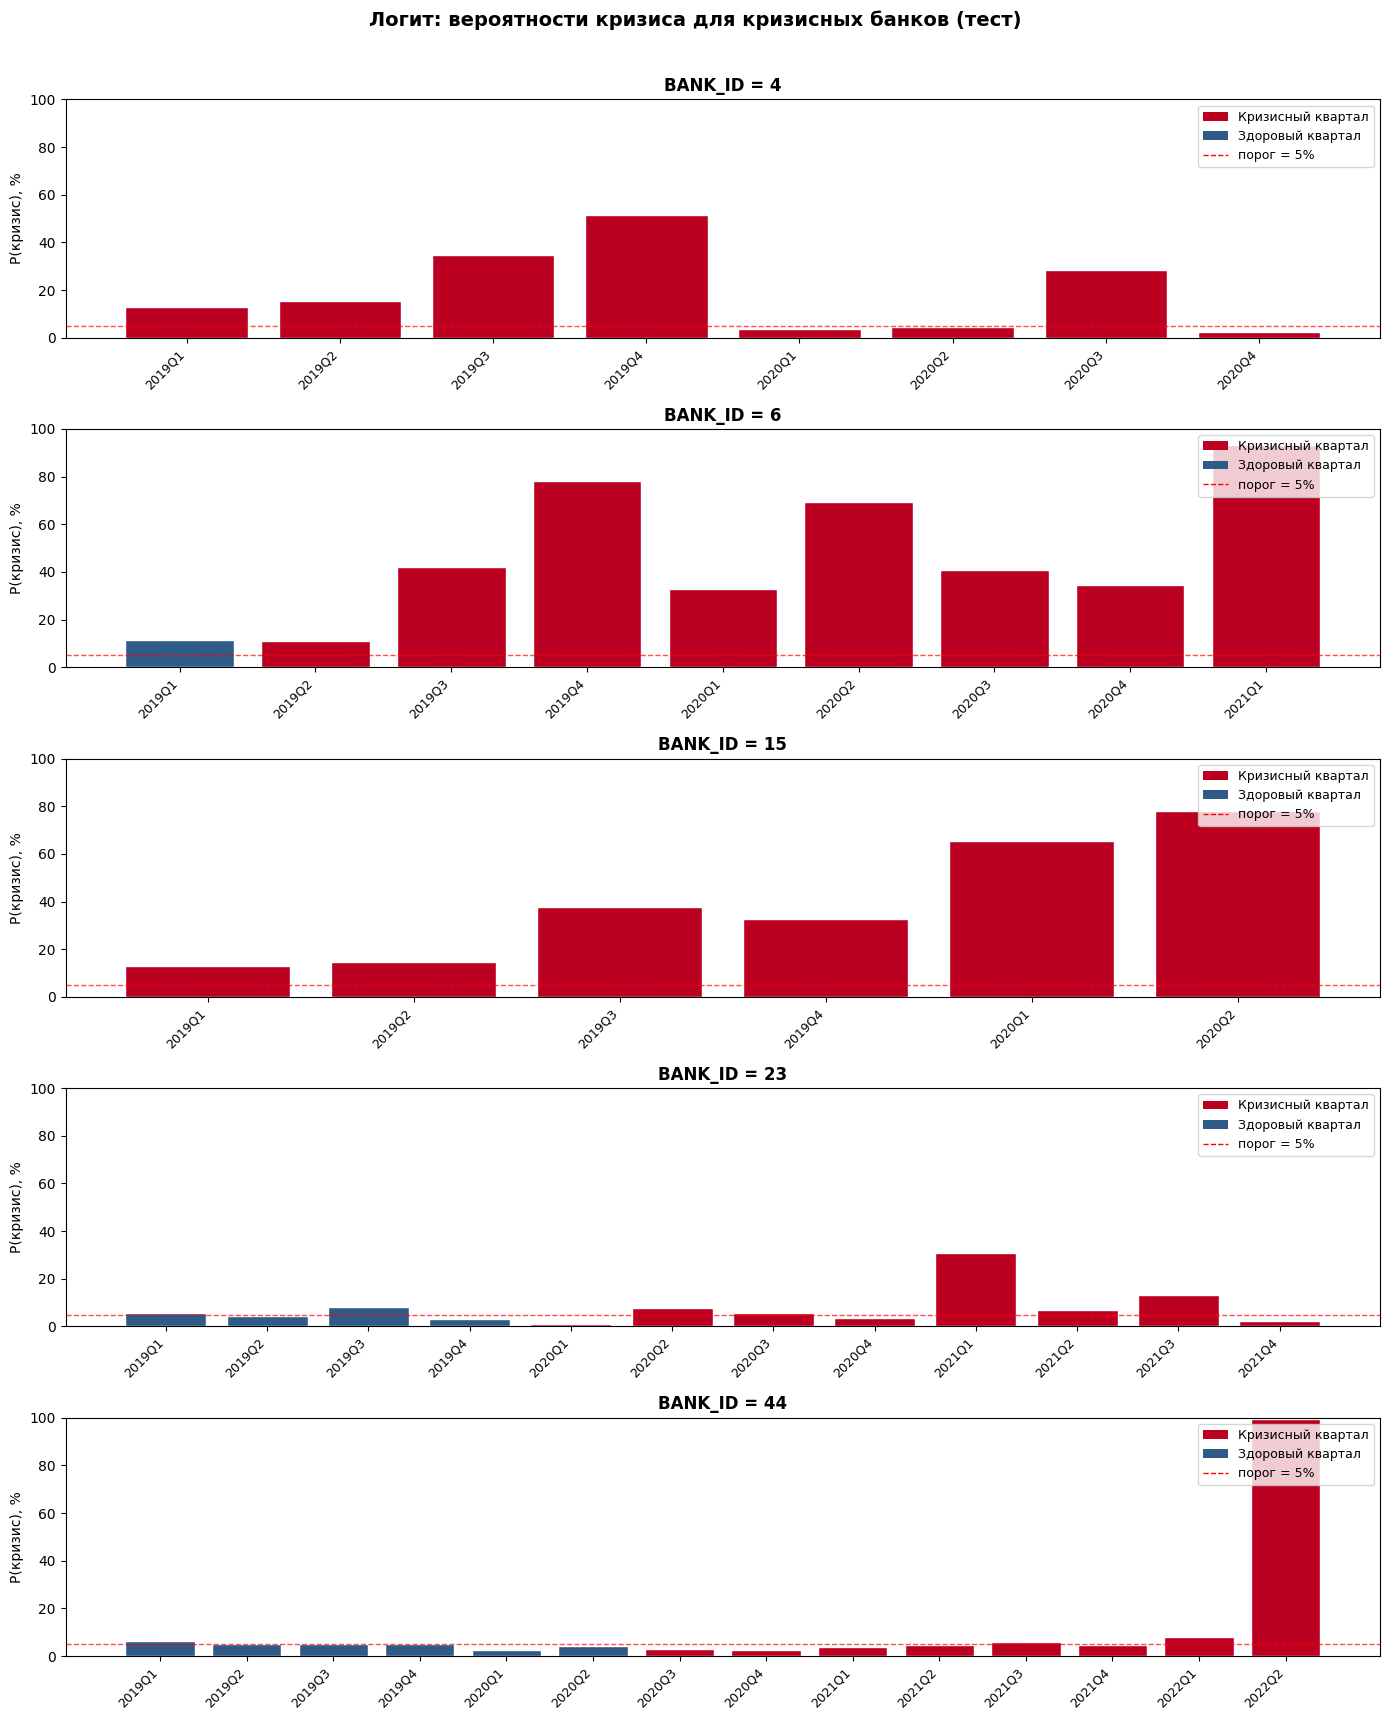

In [22]:
# === Вероятности кризисных банков по кварталам (логит, target_8q_window) ===
model_8q = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1877)
model_8q.fit(X_train_l, train['target_8q_window'].values)
test_prob = test[['BANK_ID', 'Quarter', 'target_8q_window']].copy()
test_prob['prob'] = model_8q.predict_proba(X_test_l)[:, 1]

crisis_banks = sorted(test[test.target_8q_window == 1].BANK_ID.unique())
thresh = logit_results['target_8q_window']['Threshold']

fig, axes = plt.subplots(len(crisis_banks), 1, figsize=(14, 3.5 * len(crisis_banks)))
if len(crisis_banks) == 1:
    axes = [axes]

for ax, bid in zip(axes, crisis_banks):
    bdata = test_prob[test_prob.BANK_ID == bid].sort_values('Quarter')
    quarters = bdata['Quarter'].dt.to_period('Q').astype(str)
    probs = bdata['prob'].values * 100
    is_crisis = bdata['target_8q_window'].values

    bar_colors = ['#BB0021' if c == 1 else '#2E5B88' for c in is_crisis]
    bars = ax.bar(range(len(quarters)), probs, color=bar_colors, edgecolor='white', width=0.8)
    ax.set_xticks(range(len(quarters)))
    ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('P(кризис), %')
    ax.set_ylim(0, 100)
    ax.set_title(f'BANK_ID = {bid}', fontweight='bold', fontsize=12)
    ax.axhline(y=thresh * 100, color='red', linestyle='--', linewidth=1, alpha=0.7)

    # Легенда через Patch
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_items = [
        Patch(facecolor='#BB0021', label='Кризисный квартал'),
        Patch(facecolor='#2E5B88', label='Здоровый квартал'),
        Line2D([0], [0], color='red', linestyle='--', linewidth=1, label=f'порог = {thresh*100:.0f}%')
    ]
    ax.legend(handles=legend_items, fontsize=9, loc='upper right')

fig.suptitle('Логит: вероятности кризиса для кризисных банков (тест)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig('logit_crisis_banks_proba.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

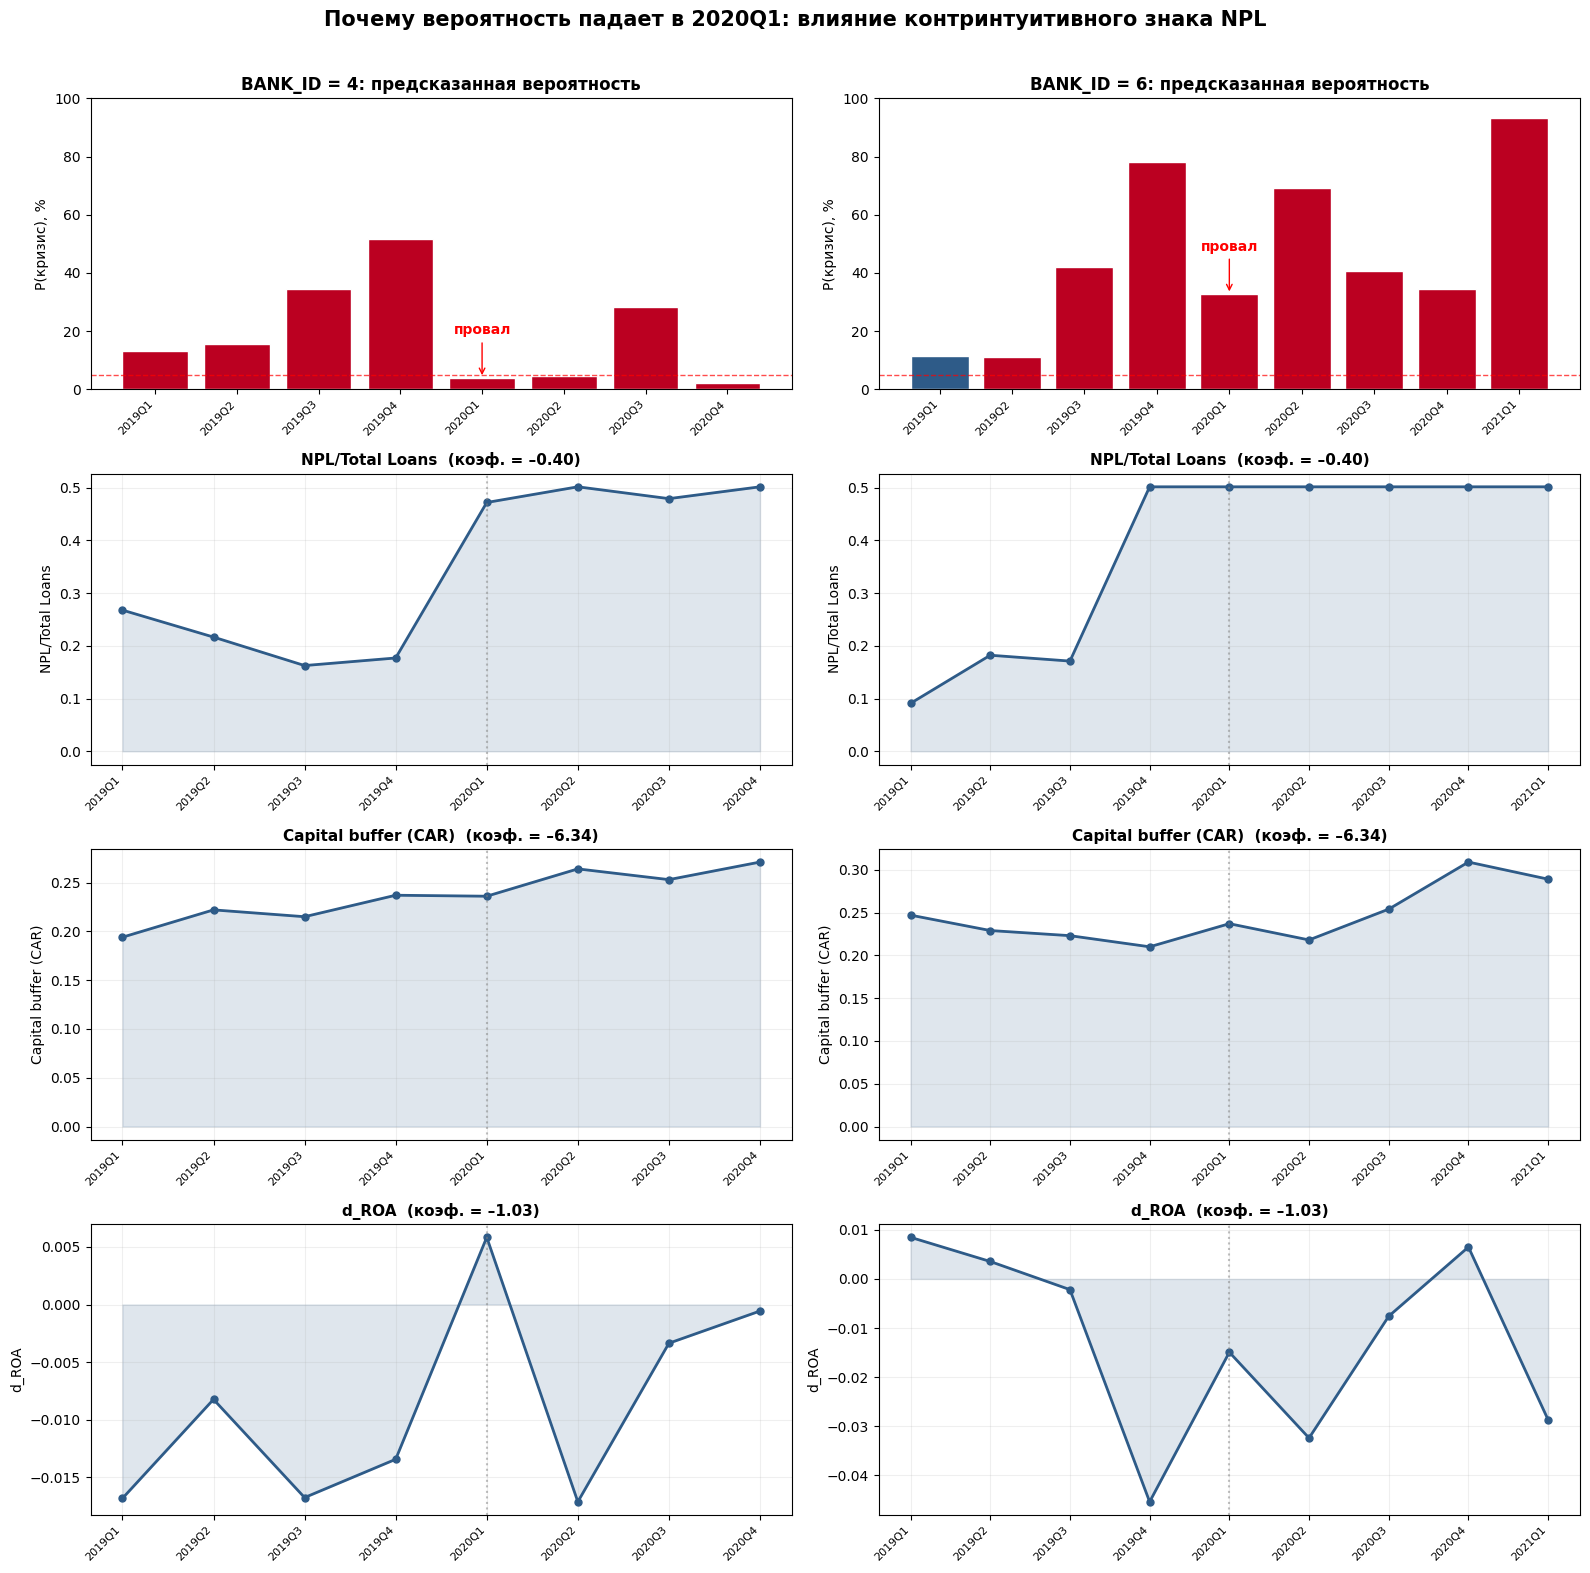

In [23]:
# === Анализ провала вероятности в 2020Q1 (банки 4, 6) ===
show_vars = ['NPL/Total Loans', 'Capital buffer (CAR)', 'd_ROA']
coef_dict = dict(zip(logit_features, logit_coefs['target_8q_window']['coef'].values))
# нужен dict feature->coef, пересоберём из модели
model_8q = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1877)
model_8q.fit(X_train_l, train['target_8q_window'].values)
coef_dict = dict(zip(logit_features, model_8q.coef_[0]))

test_prob = test[['BANK_ID', 'Quarter', 'target_8q_window']].copy()
test_prob['prob'] = model_8q.predict_proba(X_test_l)[:, 1]

fig, axes = plt.subplots(4, 2, figsize=(16, 16))

for col_idx, bid in enumerate([4, 6]):
    bdata = test.merge(test_prob[['BANK_ID', 'Quarter', 'prob']], on=['BANK_ID', 'Quarter'])
    bdata = bdata[bdata.BANK_ID == bid].sort_values('Quarter')
    quarters = bdata['Quarter'].dt.to_period('Q').astype(str)
    x = range(len(quarters))
    q_labels = list(quarters)

    # Вероятность
    ax = axes[0, col_idx]
    probs = bdata['prob'].values * 100
    is_crisis = bdata['target_8q_window'].values
    bar_colors = ['#BB0021' if c == 1 else '#2E5B88' for c in is_crisis]
    ax.bar(x, probs, color=bar_colors, edgecolor='white', width=0.8)
    ax.axhline(y=5, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_ylabel('P(кризис), %'); ax.set_ylim(0, 100)
    ax.set_title(f'BANK_ID = {bid}: предсказанная вероятность', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=8)
    if '2020Q1' in q_labels:
        idx_m = q_labels.index('2020Q1')
        ax.annotate('провал', xy=(idx_m, probs[idx_m]), xytext=(idx_m, probs[idx_m]+15),
                    ha='center', fontsize=10, color='red', fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color='red'))

    # Показатели
    for row_idx, var in enumerate(show_vars):
        ax = axes[row_idx + 1, col_idx]
        vals = bdata[var].values
        coef = coef_dict.get(var, 0)
        sign = '+' if coef > 0 else '–'
        color = '#BB0021' if coef > 0 else '#2E5B88'
        ax.plot(x, vals, marker='o', color=color, linewidth=2, markersize=5)
        ax.fill_between(x, vals, alpha=0.15, color=color)
        ax.set_ylabel(var, fontsize=10)
        ax.set_title(f'{var}  (коэф. = {sign}{abs(coef):.2f})', fontweight='bold', fontsize=11)
        ax.set_xticks(x); ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=8)
        ax.grid(True, alpha=0.2)
        if '2020Q1' in q_labels:
            ax.axvline(x=q_labels.index('2020Q1'), color='grey', linestyle=':', alpha=0.5)

fig.suptitle('Почему вероятность падает в 2020Q1: влияние контринтуитивного знака NPL',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('logit_npl_analysis.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# 2) ML

## 2.1) RF

In [24]:
# RF
X_train_ml = train[all_features].values
X_test_ml = test[all_features].values

# --- CV: expanding window ---
train_sorted = train.sort_values('Quarter').reset_index(drop=True)
X_sorted = train_sorted[all_features].values
y_sorted = train_sorted['target_8q_window'].values

tscv = TimeSeriesSplit(n_splits=2)
print("Фолды CV:")
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_sorted)):
    tr_dates = train_sorted.iloc[tr_idx]['Quarter']
    val_dates = train_sorted.iloc[val_idx]['Quarter']
    print(f"  Fold {i+1}: train {tr_dates.min().date()}–{tr_dates.max().date()} "
          f"({len(tr_idx)} набл., {int(y_sorted[tr_idx].sum())} кризис), "
          f"val {val_dates.min().date()}–{val_dates.max().date()} "
          f"({len(val_idx)} набл., {int(y_sorted[val_idx].sum())} кризис)")

params_list = [
    {'n_estimators': 300, 'max_depth': 5, 'min_samples_leaf': 5},
    {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3},
    {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 3},
    {'n_estimators': 500, 'max_depth': 8, 'min_samples_leaf': 5},
    {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 5},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 5},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 10},
]

best_cv_auc, best_params = -1, None
for p in params_list:
    scores = []
    for tr_idx, val_idx in tscv.split(X_sorted):
        if y_sorted[tr_idx].sum() == 0 or y_sorted[val_idx].sum() == 0:
            continue
        m = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, **p)
        m.fit(X_sorted[tr_idx], y_sorted[tr_idx])
        scores.append(roc_auc_score(y_sorted[val_idx], m.predict_proba(X_sorted[val_idx])[:, 1]))
    if scores:
        mean_s = np.mean(scores)
        print(f"  {p} → CV AUC = {mean_s:.3f}")
        if mean_s > best_cv_auc:
            best_cv_auc = mean_s
            best_params = p

print(f"\nBest RF: {best_params}, CV AUC = {best_cv_auc:.3f}")

rf_results = {}
rf_models = {}

for target in target_cols:
    rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, **best_params)
    rf.fit(X_train_ml, train[target].values)
    rf_results[target] = evaluate(test[target].values, rf.predict_proba(X_test_ml)[:, 1])
    rf_models[target] = rf

print("\nРезультаты RF:")
print_results("RF", rf_results)

fi = pd.DataFrame({'feature': all_features,
                    'importance': rf_models['target_8q_window'].feature_importances_})
fi = fi.sort_values('importance', ascending=False)


comp = pd.DataFrame({
    'Logit': logit_results['target_8q_window'],
    'RF': rf_results['target_8q_window']}).T
print(comp[['AUC', 'F2', 'Precision', 'Recall', 'Threshold']].to_string())

Фолды CV:
  Fold 1: train 2011-12-31–2014-03-31 (272 набл., 0 кризис), val 2014-03-31–2016-06-30 (270 набл., 25 кризис)
  Fold 2: train 2011-12-31–2016-06-30 (542 набл., 25 кризис), val 2016-06-30–2018-12-31 (270 набл., 73 кризис)
  {'n_estimators': 300, 'max_depth': 5, 'min_samples_leaf': 5} → CV AUC = 0.838
  {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 3} → CV AUC = 0.822
  {'n_estimators': 500, 'max_depth': 5, 'min_samples_leaf': 3} → CV AUC = 0.830
  {'n_estimators': 500, 'max_depth': 8, 'min_samples_leaf': 5} → CV AUC = 0.832
  {'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 5} → CV AUC = 0.827
  {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 5} → CV AUC = 0.827
  {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 10} → CV AUC = 0.828

Best RF: {'n_estimators': 300, 'max_depth': 5, 'min_samples_leaf': 5}, CV AUC = 0.838

Результаты RF:
  target_8q_window          AUC=0.782  F2=0.538  Prec=0.189  Rec=1.0  Brier=0.084  Thresh=0.08  TN

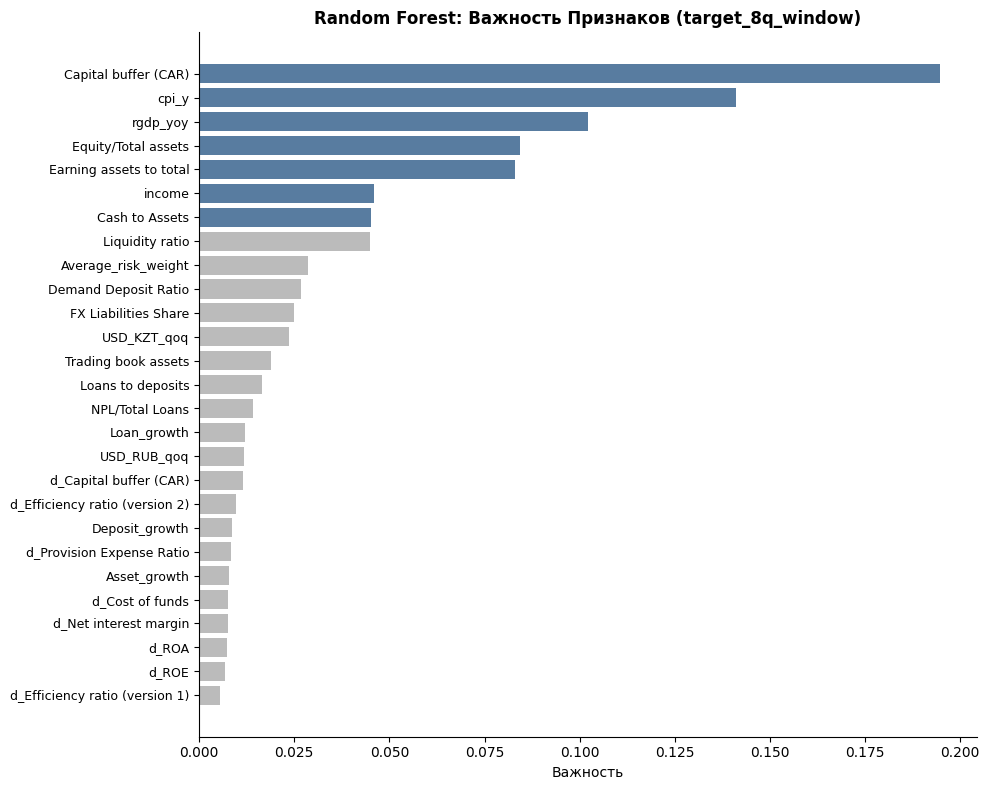

In [25]:
fi_sorted = fi.sort_values('importance')
fi_sorted = fi_sorted.rename(columns={'feature':'Признак', 'importance':'Важность'})
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2E5B88' if imp >= fi['importance'].quantile(0.75) else '#aaaaaa'
          for imp in fi_sorted['Важность']]
ax.barh(range(len(fi_sorted)), fi_sorted['Важность'], color=colors, alpha=0.8)
ax.set_yticks(range(len(fi_sorted)))
ax.set_yticklabels(fi_sorted['Признак'], fontsize=9)
ax.set_xlabel('Важность')
ax.set_title('Random Forest: Важность Признаков (target_8q_window)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('rf_feature_importance.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

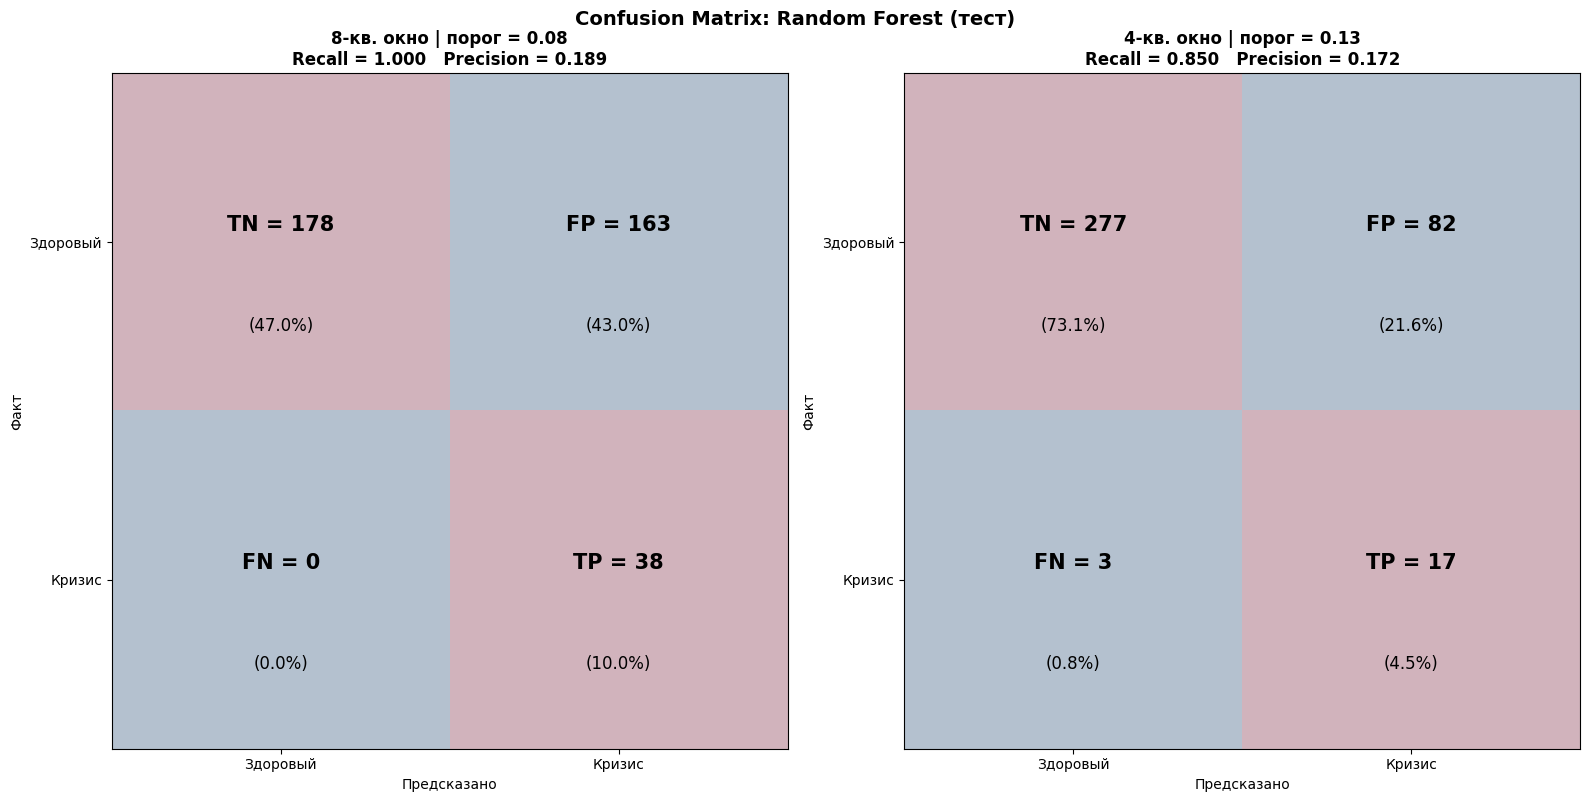

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
labels = ['8-кв. окно', '4-кв. окно'] # , '8-кв. точка', '4-кв. точка'
cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for ax, target, label in zip(axes.flatten(), target_cols, labels):
    r = rf_results[target]
    cm = np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])
    prec = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    rec = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0

    ax.imshow([[0, 1], [1, 0]], cmap='RdBu', alpha=0.3, extent=[0, 2, 0, 2])
    for row in range(2):
        for col in range(2):
            val = cm[row, col]
            pct = val / cm.sum() * 100
            ax.text(col + 0.5, 1.55 - row, f'{cell_labels[row][col]} = {val}',
                    ha='center', va='center', fontsize=15, fontweight='bold')
            ax.text(col + 0.5, 1.25 - row, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=12)

    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Здоровый', 'Кризис'])
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['Кризис', 'Здоровый'])
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Факт')
    ax.set_title(f'{label} | порог = {r["Threshold"]}\n'
                 f'Recall = {rec:.3f}   Precision = {prec:.3f}', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrix: Random Forest (тест)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('rf_confusion_matrices.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

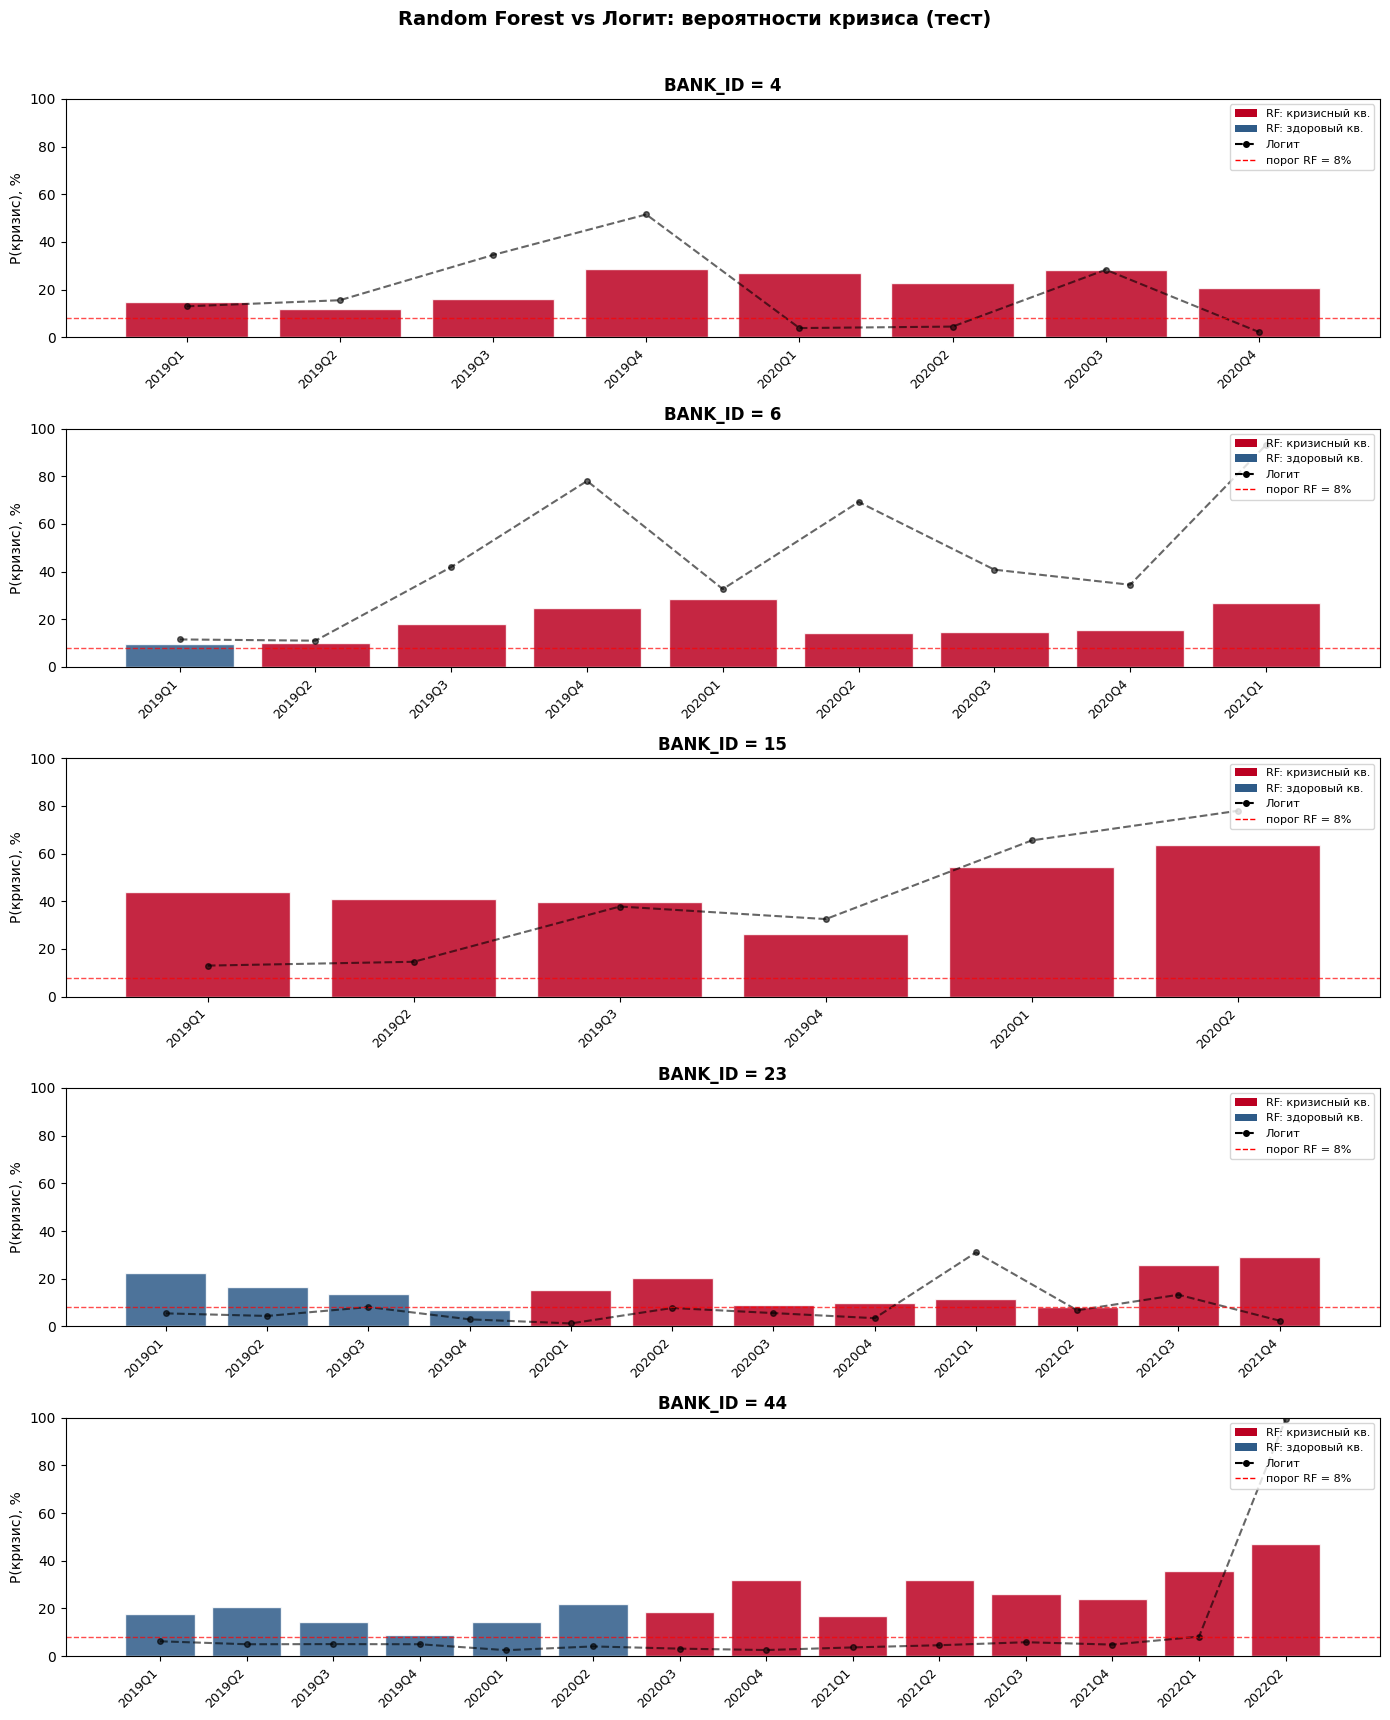

In [27]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

test_prob_rf = test[['BANK_ID', 'Quarter', 'target_8q_window']].copy()
test_prob_rf['prob_rf'] = rf_models['target_8q_window'].predict_proba(X_test_ml)[:, 1]

model_8q_logit = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=1877)
model_8q_logit.fit(X_train_l, train['target_8q_window'].values)
test_prob_rf['prob_logit'] = model_8q_logit.predict_proba(X_test_l)[:, 1]

crisis_banks = sorted(test[test.target_8q_window == 1].BANK_ID.unique())
thresh_rf = rf_results['target_8q_window']['Threshold']

fig, axes = plt.subplots(len(crisis_banks), 1, figsize=(14, 3.5 * len(crisis_banks)))
if len(crisis_banks) == 1:
    axes = [axes]

for ax, bid in zip(axes, crisis_banks):
    bdata = test_prob_rf[test_prob_rf.BANK_ID == bid].sort_values('Quarter')
    quarters = bdata['Quarter'].dt.to_period('Q').astype(str)
    x = range(len(quarters))
    probs_rf = bdata['prob_rf'].values * 100
    probs_logit = bdata['prob_logit'].values * 100
    is_crisis = bdata['target_8q_window'].values

    bar_colors = ['#BB0021' if c == 1 else '#2E5B88' for c in is_crisis]
    ax.bar(x, probs_rf, color=bar_colors, edgecolor='white', width=0.8, alpha=0.85)
    ax.plot(x, probs_logit, color='black', marker='o', markersize=4, linewidth=1.5,
            linestyle='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('P(кризис), %')
    ax.set_ylim(0, 100)
    ax.set_title(f'BANK_ID = {bid}', fontweight='bold', fontsize=12)
    ax.axhline(y=thresh_rf * 100, color='red', linestyle='--', linewidth=1, alpha=0.7)

    legend_items = [
        Patch(facecolor='#BB0021', label='RF: кризисный кв.'),
        Patch(facecolor='#2E5B88', label='RF: здоровый кв.'),
        Line2D([0], [0], color='black', linestyle='--', marker='o', markersize=4, label='Логит'),
        Line2D([0], [0], color='red', linestyle='--', linewidth=1, label=f'порог RF = {thresh_rf*100:.0f}%')
    ]
    ax.legend(handles=legend_items, fontsize=8, loc='upper right')

fig.suptitle('Random Forest vs Логит: вероятности кризиса (тест)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig('rf_crisis_banks_proba.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 2.2) BRF

In [28]:
from imblearn.ensemble import BalancedRandomForestClassifier

brf_results = {}
brf_models = {}

for target in target_cols:
    brf = BalancedRandomForestClassifier(random_state=1877, n_jobs=-1, **best_params)
    brf.fit(X_train_ml, train[target].values)
    brf_results[target] = evaluate(test[target].values, brf.predict_proba(X_test_ml)[:, 1])
    brf_models[target] = brf

print("\nРезультаты BRF:")
print_results("BRF", brf_results)

# --- Сравнение Logit vs RF vs BRF ---
comp = pd.DataFrame({
    'Logit': logit_results['target_8q_window'],
    'RF': rf_results['target_8q_window'],
    'BRF': brf_results['target_8q_window']
}).T
print(comp[['AUC', 'F2', 'Precision', 'Recall', 'Threshold']].to_string())


Результаты BRF:
  target_8q_window          AUC=0.772  F2=0.541  Prec=0.21  Rec=0.895  Brier=0.094  Thresh=0.19  TN=213 FP=128 FN=4 TP=34
  target_4q_window          AUC=0.854  F2=0.5  Prec=0.26  Rec=0.65  Brier=0.066  Thresh=0.35  TN=322 FP=37 FN=7 TP=13
  target_8q_point           AUC=0.653  F2=0.1  Prec=0.029  Rec=0.25  Brier=0.094  Thresh=0.43  TN=342 FP=33 FN=3 TP=1
  target_4q_point           AUC=0.651  F2=0.117  Prec=0.028  Rec=0.6  Brier=0.093  Thresh=0.33  TN=269 FP=105 FN=2 TP=3
         AUC     F2  Precision  Recall  Threshold
Logit  0.772  0.453      0.185   0.711       0.05
RF     0.782  0.538      0.189   1.000       0.08
BRF    0.772  0.541      0.210   0.895       0.19


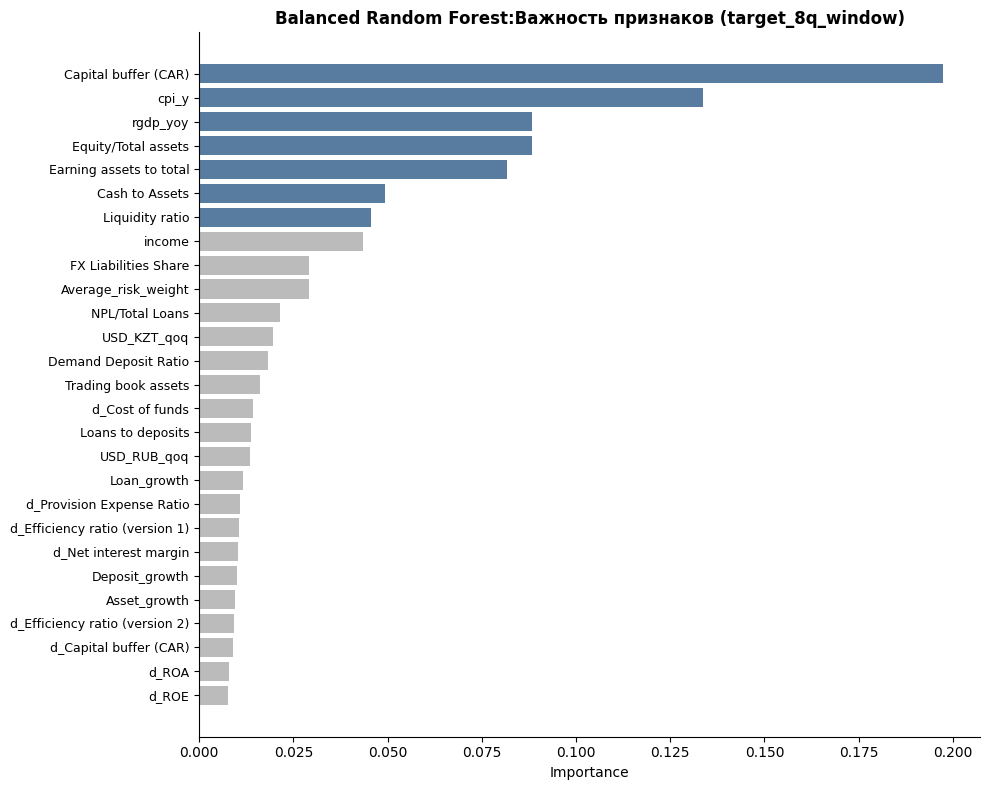

In [29]:
fi_brf = pd.DataFrame({'feature': all_features,
                        'importance': brf_models['target_8q_window'].feature_importances_})
fi_brf = fi_brf.sort_values('importance', ascending=False)

fi_brf_sorted = fi_brf.sort_values('importance')
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2E5B88' if imp >= fi_brf['importance'].quantile(0.75) else '#aaaaaa'
          for imp in fi_brf_sorted['importance']]
ax.barh(range(len(fi_brf_sorted)), fi_brf_sorted['importance'], color=colors, alpha=0.8)
ax.set_yticks(range(len(fi_brf_sorted)))
ax.set_yticklabels(fi_brf_sorted['feature'], fontsize=9)
ax.set_xlabel('Importance')
ax.set_title('Balanced Random Forest:Важность признаков (target_8q_window)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('brf_feature_importance.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


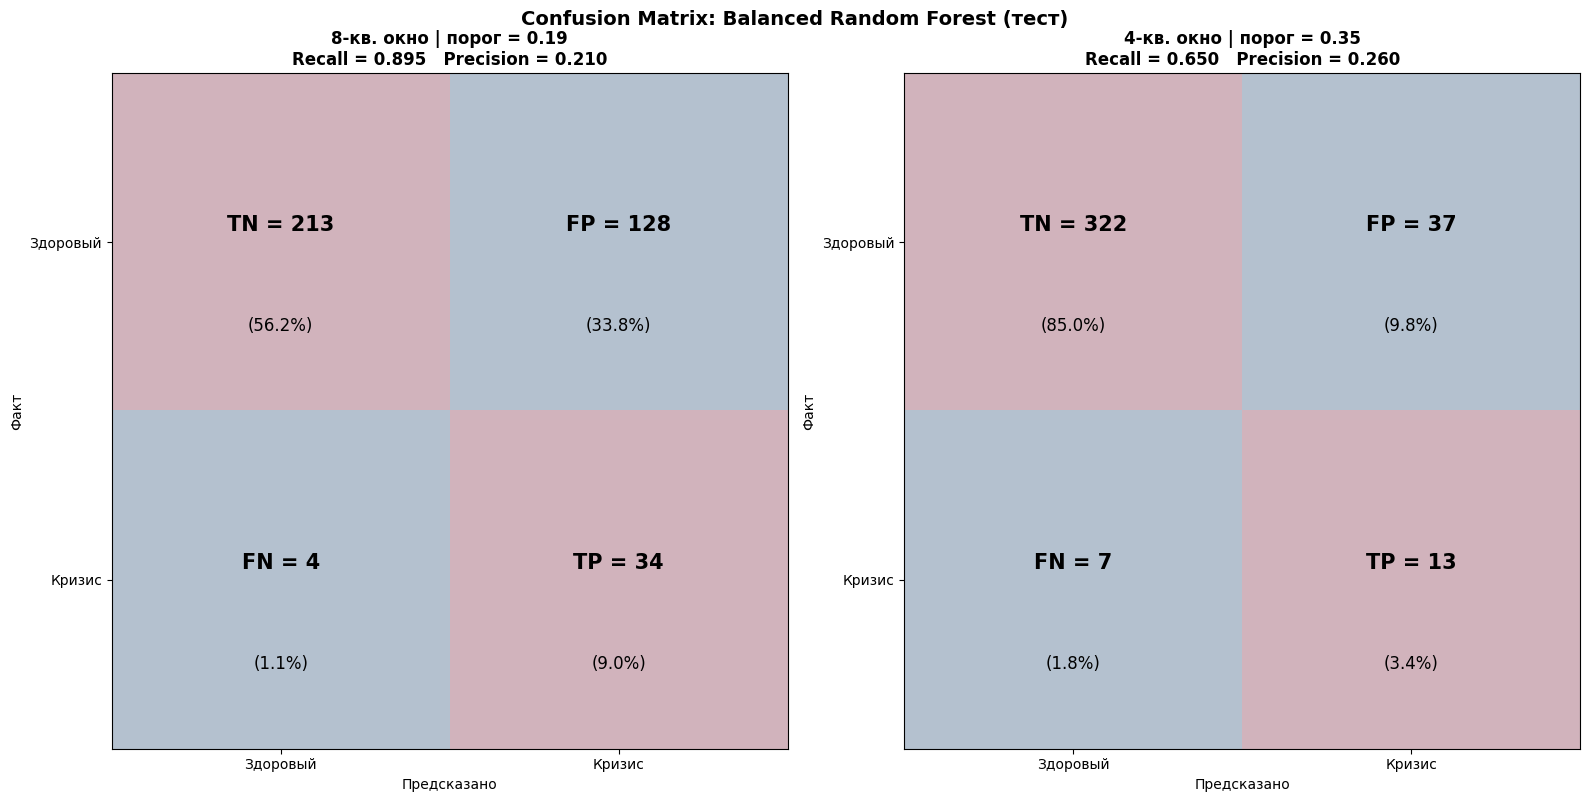

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
labels = ['8-кв. окно', '4-кв. окно'] # , '8-кв. точка', '4-кв. точка'
cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for ax, target, label in zip(axes.flatten(), target_cols, labels):
    r = brf_results[target]
    cm = np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])
    prec = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    rec = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0

    ax.imshow([[0, 1], [1, 0]], cmap='RdBu', alpha=0.3, extent=[0, 2, 0, 2])
    for row in range(2):
        for col in range(2):
            val = cm[row, col]
            pct = val / cm.sum() * 100
            ax.text(col + 0.5, 1.55 - row, f'{cell_labels[row][col]} = {val}',
                    ha='center', va='center', fontsize=15, fontweight='bold')
            ax.text(col + 0.5, 1.25 - row, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=12)

    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Здоровый', 'Кризис'])
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['Кризис', 'Здоровый'])
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Факт')
    ax.set_title(f'{label} | порог = {r["Threshold"]}\n'
                 f'Recall = {rec:.3f}   Precision = {prec:.3f}', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrix: Balanced Random Forest (тест)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('brf_confusion_matrices.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


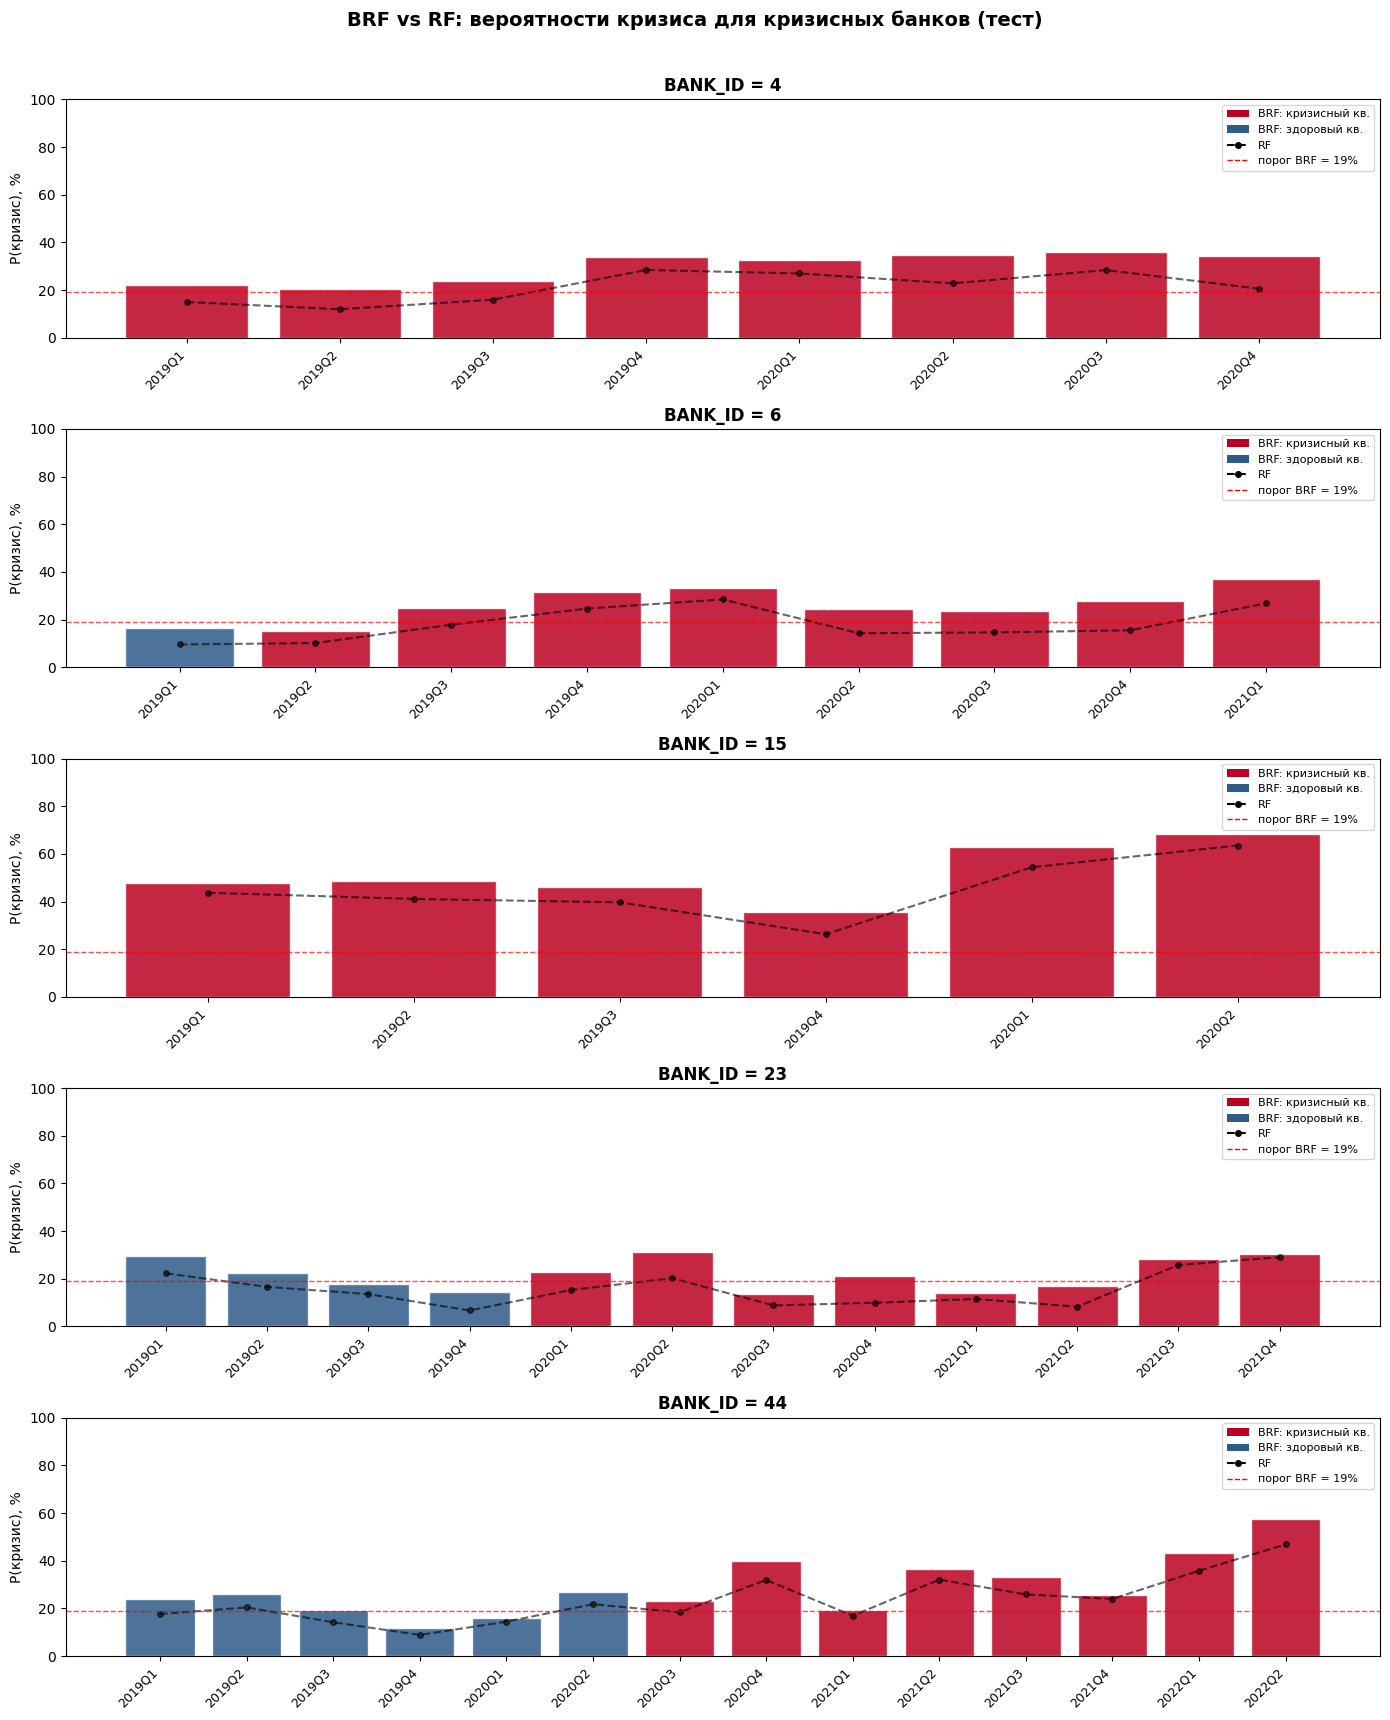

In [31]:
test_prob_brf = test[['BANK_ID', 'Quarter', 'target_8q_window']].copy()
test_prob_brf['prob_brf'] = brf_models['target_8q_window'].predict_proba(X_test_ml)[:, 1]
test_prob_brf['prob_rf'] = rf_models['target_8q_window'].predict_proba(X_test_ml)[:, 1]

crisis_banks = sorted(test[test.target_8q_window == 1].BANK_ID.unique())
thresh_brf = brf_results['target_8q_window']['Threshold']

fig, axes = plt.subplots(len(crisis_banks), 1, figsize=(14, 3.5 * len(crisis_banks)))
if len(crisis_banks) == 1:
    axes = [axes]

for ax, bid in zip(axes, crisis_banks):
    bdata = test_prob_brf[test_prob_brf.BANK_ID == bid].sort_values('Quarter')
    quarters = bdata['Quarter'].dt.to_period('Q').astype(str)
    x = range(len(quarters))
    probs_brf = bdata['prob_brf'].values * 100
    probs_rf = bdata['prob_rf'].values * 100
    is_crisis = bdata['target_8q_window'].values

    bar_colors = ['#BB0021' if c == 1 else '#2E5B88' for c in is_crisis]
    ax.bar(x, probs_brf, color=bar_colors, edgecolor='white', width=0.8, alpha=0.85)
    ax.plot(x, probs_rf, color='black', marker='o', markersize=4, linewidth=1.5,
            linestyle='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('P(кризис), %')
    ax.set_ylim(0, 100)
    ax.set_title(f'BANK_ID = {bid}', fontweight='bold', fontsize=12)
    ax.axhline(y=thresh_brf * 100, color='red', linestyle='--', linewidth=1, alpha=0.7)

    legend_items = [
        Patch(facecolor='#BB0021', label='BRF: кризисный кв.'),
        Patch(facecolor='#2E5B88', label='BRF: здоровый кв.'),
        Line2D([0], [0], color='black', linestyle='--', marker='o', markersize=4, label='RF'),
        Line2D([0], [0], color='red', linestyle='--', linewidth=1, label=f'порог BRF = {thresh_brf*100:.0f}%')
    ]
    ax.legend(handles=legend_items, fontsize=8, loc='upper right')

fig.suptitle('BRF vs RF: вероятности кризиса для кризисных банков (тест)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig('brf_crisis_banks_proba.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## 2.3) Catboost

In [32]:
from catboost import CatBoostClassifier

# --- CV для подбора гиперпараметров ---
cb_params_list = [
    {'iterations': 300, 'depth': 4, 'learning_rate': 0.05},
    {'iterations': 300, 'depth': 6, 'learning_rate': 0.05},
    {'iterations': 500, 'depth': 4, 'learning_rate': 0.03},
    {'iterations': 500, 'depth': 6, 'learning_rate': 0.03},
    {'iterations': 500, 'depth': 4, 'learning_rate': 0.05},
    {'iterations': 500, 'depth': 6, 'learning_rate': 0.05},
]

best_cb_auc, best_cb_params = -1, None
for p in cb_params_list:
    scores = []
    for tr_idx, val_idx in tscv.split(X_sorted):
        if y_sorted[tr_idx].sum() == 0 or y_sorted[val_idx].sum() == 0:
            continue
        m = CatBoostClassifier(auto_class_weights='Balanced', random_seed=1877,
                               verbose=0, **p)
        m.fit(X_sorted[tr_idx], y_sorted[tr_idx])
        scores.append(roc_auc_score(y_sorted[val_idx], m.predict_proba(X_sorted[val_idx])[:, 1]))
    if scores:
        mean_s = np.mean(scores)
        print(f"  {p} → CV AUC = {mean_s:.3f}")
        if mean_s > best_cb_auc:
            best_cb_auc = mean_s
            best_cb_params = p

print(f"\nBest CatBoost: {best_cb_params}, CV AUC = {best_cb_auc:.3f}")

cb_results = {}
cb_models = {}

for target in target_cols:
    cb = CatBoostClassifier(auto_class_weights='Balanced', random_seed=42,
                            verbose=0, **best_cb_params)
    cb.fit(X_train_ml, train[target].values)
    cb_results[target] = evaluate(test[target].values, cb.predict_proba(X_test_ml)[:, 1])
    cb_models[target] = cb

print_results("CatBoost", cb_results)

fi_cb = pd.DataFrame({'feature': all_features,
                       'importance': cb_models['target_8q_window'].get_feature_importance()})
fi_cb = fi_cb.sort_values('importance', ascending=False)
print(f"\nCatBoost Feature Importance (top 10):")
print(fi_cb.head(10).round(2).to_string(index=False))

comp = pd.DataFrame({
    'Logit': logit_results['target_8q_window'],
    'RF': rf_results['target_8q_window'],
    'BRF': brf_results['target_8q_window'],
    'CatBoost': cb_results['target_8q_window']
}).T
print(comp[['AUC', 'F2', 'Precision', 'Recall', 'Threshold']].to_string())

  {'iterations': 300, 'depth': 4, 'learning_rate': 0.05} → CV AUC = 0.811
  {'iterations': 300, 'depth': 6, 'learning_rate': 0.05} → CV AUC = 0.831
  {'iterations': 500, 'depth': 4, 'learning_rate': 0.03} → CV AUC = 0.810
  {'iterations': 500, 'depth': 6, 'learning_rate': 0.03} → CV AUC = 0.828
  {'iterations': 500, 'depth': 4, 'learning_rate': 0.05} → CV AUC = 0.807
  {'iterations': 500, 'depth': 6, 'learning_rate': 0.05} → CV AUC = 0.831

Best CatBoost: {'iterations': 300, 'depth': 6, 'learning_rate': 0.05}, CV AUC = 0.831
  target_8q_window          AUC=0.856  F2=0.309  Prec=0.423  Rec=0.289  Brier=0.082  Thresh=0.05  TN=326 FP=15 FN=27 TP=11
  target_4q_window          AUC=0.895  F2=0.275  Prec=0.455  Rec=0.25  Brier=0.045  Thresh=0.07  TN=353 FP=6 FN=15 TP=5
  target_8q_point           AUC=0.653  F2=0  Prec=0.0  Rec=0.0  Brier=0.01  Thresh=0.5  TN=375 FP=0 FN=4 TP=0
  target_4q_point           AUC=0.585  F2=0  Prec=0.0  Rec=0.0  Brier=0.013  Thresh=0.5  TN=374 FP=0 FN=5 TP=0

CatB

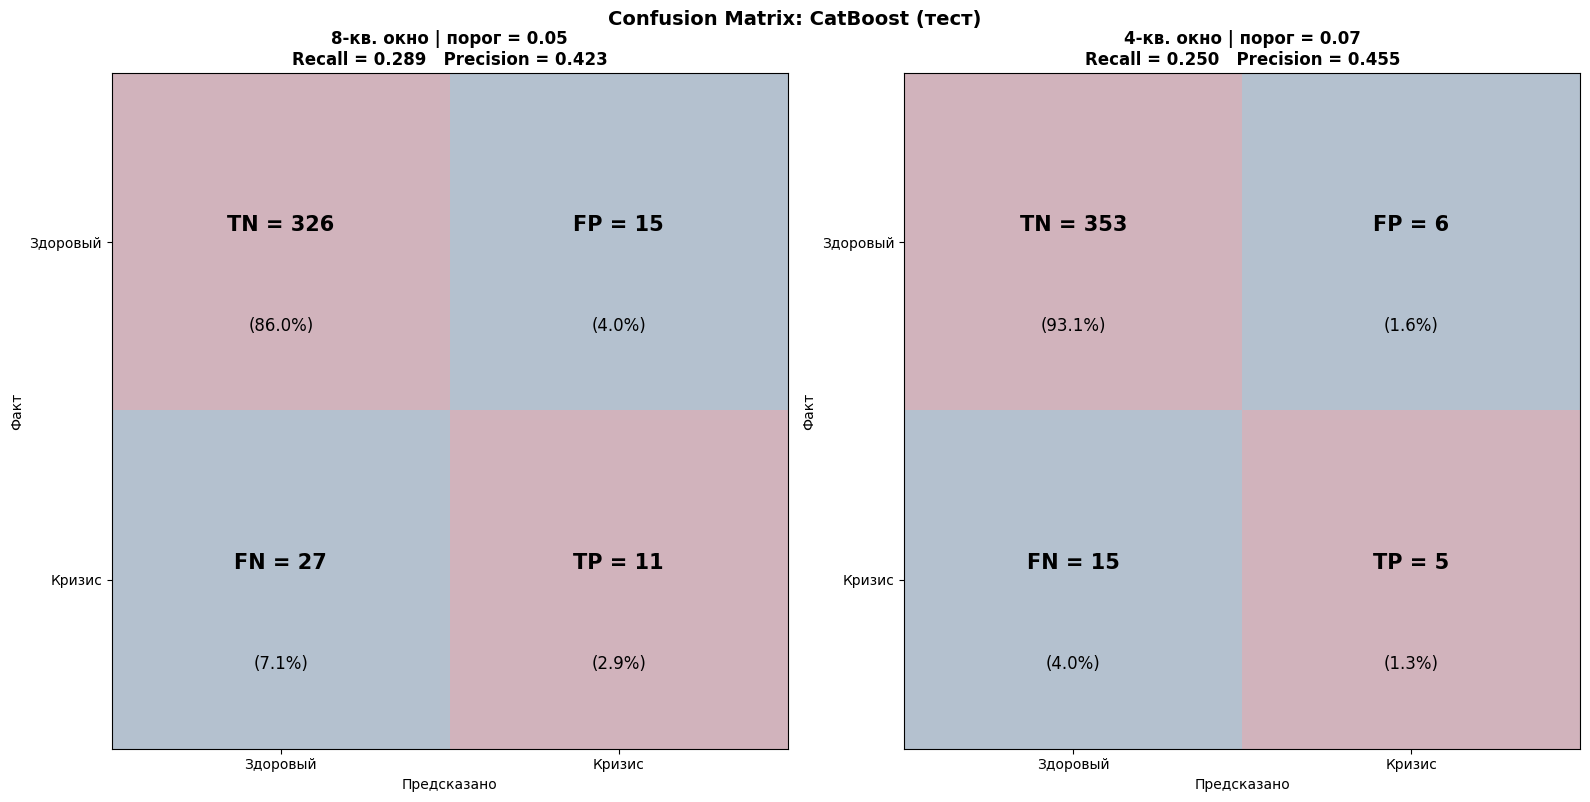

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
labels = ['8-кв. окно', '4-кв. окно'] # , '8-кв. точка', '4-кв. точка'
cell_labels = [['TN', 'FP'], ['FN', 'TP']]

for ax, target, label in zip(axes.flatten(), target_cols, labels):
    r = cb_results[target]
    cm = np.array([[r['TN'], r['FP']], [r['FN'], r['TP']]])
    prec = cm[1,1] / (cm[1,1] + cm[0,1]) if (cm[1,1] + cm[0,1]) > 0 else 0
    rec = cm[1,1] / (cm[1,1] + cm[1,0]) if (cm[1,1] + cm[1,0]) > 0 else 0

    ax.imshow([[0, 1], [1, 0]], cmap='RdBu', alpha=0.3, extent=[0, 2, 0, 2])
    for row in range(2):
        for col in range(2):
            val = cm[row, col]
            pct = val / cm.sum() * 100
            ax.text(col + 0.5, 1.55 - row, f'{cell_labels[row][col]} = {val}',
                    ha='center', va='center', fontsize=15, fontweight='bold')
            ax.text(col + 0.5, 1.25 - row, f'({pct:.1f}%)',
                    ha='center', va='center', fontsize=12)

    ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['Здоровый', 'Кризис'])
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['Кризис', 'Здоровый'])
    ax.set_xlabel('Предсказано'); ax.set_ylabel('Факт')
    ax.set_title(f'{label} | порог = {r["Threshold"]}\n'
                 f'Recall = {rec:.3f}   Precision = {prec:.3f}', fontweight='bold', fontsize=12)

plt.suptitle('Confusion Matrix: CatBoost (тест)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('cb_confusion_matrices.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

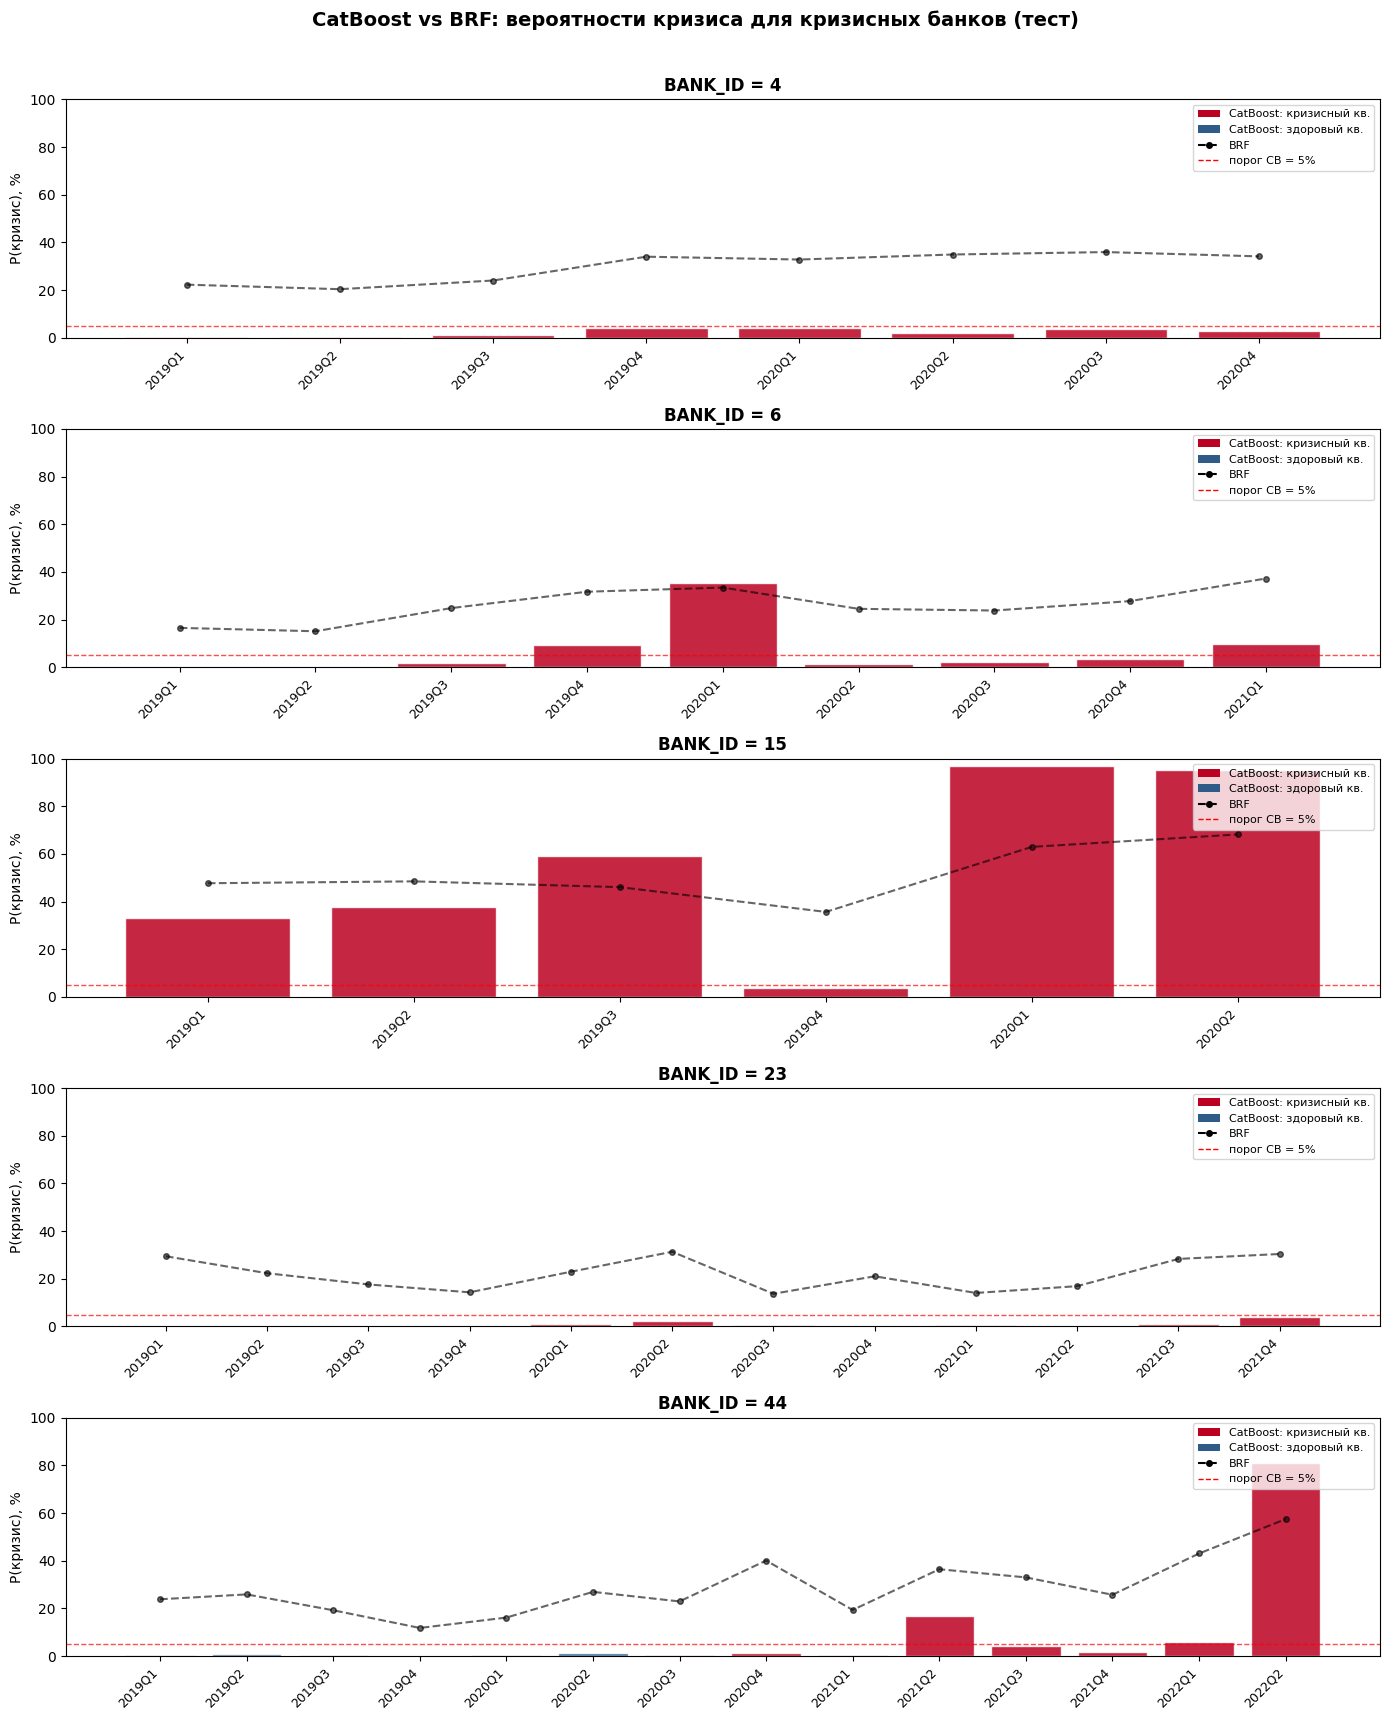

In [34]:
test_prob_cb = test[['BANK_ID', 'Quarter', 'target_8q_window']].copy()
test_prob_cb['prob_cb'] = cb_models['target_8q_window'].predict_proba(X_test_ml)[:, 1]
test_prob_cb['prob_brf'] = brf_models['target_8q_window'].predict_proba(X_test_ml)[:, 1]

crisis_banks = sorted(test[test.target_8q_window == 1].BANK_ID.unique())
thresh_cb = cb_results['target_8q_window']['Threshold']

fig, axes = plt.subplots(len(crisis_banks), 1, figsize=(14, 3.5 * len(crisis_banks)))
if len(crisis_banks) == 1:
    axes = [axes]

for ax, bid in zip(axes, crisis_banks):
    bdata = test_prob_cb[test_prob_cb.BANK_ID == bid].sort_values('Quarter')
    quarters = bdata['Quarter'].dt.to_period('Q').astype(str)
    x = range(len(quarters))
    probs_cb = bdata['prob_cb'].values * 100
    probs_brf = bdata['prob_brf'].values * 100
    is_crisis = bdata['target_8q_window'].values

    bar_colors = ['#BB0021' if c == 1 else '#2E5B88' for c in is_crisis]
    ax.bar(x, probs_cb, color=bar_colors, edgecolor='white', width=0.8, alpha=0.85)
    ax.plot(x, probs_brf, color='black', marker='o', markersize=4, linewidth=1.5,
            linestyle='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('P(кризис), %')
    ax.set_ylim(0, 100)
    ax.set_title(f'BANK_ID = {bid}', fontweight='bold', fontsize=12)
    ax.axhline(y=thresh_cb * 100, color='red', linestyle='--', linewidth=1, alpha=0.7)

    legend_items = [
        Patch(facecolor='#BB0021', label='CatBoost: кризисный кв.'),
        Patch(facecolor='#2E5B88', label='CatBoost: здоровый кв.'),
        Line2D([0], [0], color='black', linestyle='--', marker='o', markersize=4, label='BRF'),
        Line2D([0], [0], color='red', linestyle='--', linewidth=1, label=f'порог CB = {thresh_cb*100:.0f}%')
    ]
    ax.legend(handles=legend_items, fontsize=8, loc='upper right')

fig.suptitle('CatBoost vs BRF: вероятности кризиса для кризисных банков (тест)',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig('cb_crisis_banks_proba.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# 3) Models improvement

In [35]:
# Анализ ошибок BRF и Catboost
# Детальный анализ ошибок
# ====================================================
# ШАГ 0: АНАЛИЗ FP И FN
# ====================================================
print("="*70)
print("Шаг 6: Анализ FP (BRF) и FN (CatBoost)")
print("="*70)

prob_brf_int = brf_models['target_8q_window'].predict_proba(X_test_ml)[:, 1]
y_test_int = test['target_8q_window'].values
thresh_brf = 0.19

fp_mask = (prob_brf_int >= thresh_brf) & (y_test_int == 0)
tp_mask = (prob_brf_int >= thresh_brf) & (y_test_int == 1)
tn_mask = (prob_brf_int < thresh_brf) & (y_test_int == 0)


# Таблица 13: FP и FN по банкам
prob_cb_test = cb_models['target_8q_window'].predict_proba(X_test_ml)[:, 1]
thresh_cb = cb_results['target_8q_window']['Threshold']
y_test_cb = test['target_8q_window'].values

fn_mask_cb = (prob_cb_test < thresh_cb) & (y_test_cb == 1)

print("\nТаблица 13. FP и FN по банкам:")
print(f"{'BANK_ID':>8} {'Набл.':>6} {'Кризис':>7} {'BRF_FP':>7} {'BRF_FN':>7} {'CB_FP':>6} {'CB_FN':>6}")
all_bank_ids = sorted(set(test['BANK_ID'].unique()))
for bid in all_bank_ids:
    mask_b = test['BANK_ID'].values == bid
    mask_b_cb = test['BANK_ID'].values == bid
    brf_fp = ((prob_brf_int >= 0.19) & (y_test_int == 0) & mask_b).sum()
    brf_fn = ((prob_brf_int < 0.19) & (y_test_int == 1) & mask_b).sum()
    cb_fp = ((prob_cb_test >= thresh_cb) & (y_test_cb == 0) & mask_b_cb).sum()
    cb_fn = ((prob_cb_test < thresh_cb) & (y_test_cb == 1) & mask_b_cb).sum()
    total = mask_b.sum()
    crisis = (y_test_int[mask_b] == 1).sum()
    if brf_fp + brf_fn + cb_fp + cb_fn > 0:
        print(f"{bid:>8} {total:>6} {crisis:>7} {brf_fp:>7} {brf_fn:>7} {cb_fp:>6} {cb_fn:>6}")


Шаг 6: Анализ FP (BRF) и FN (CatBoost)

Таблица 13. FP и FN по банкам:
 BANK_ID  Набл.  Кризис  BRF_FP  BRF_FN  CB_FP  CB_FN
       3     28       0      11       0      0      0
       4      8       8       0       0      0      8
       5     13       0      13       0      6      0
       6      9       8       0       1      0      5
      10     28       0      12       0      0      0
      11     28       0      26       0      1      0
      13     28       0      26       0      3      0
      15      6       6       0       0      0      1
      23     12       8       2       3      0      8
      32     28       0      13       0      0      0
      38     28       0      17       0      5      0
      43      9       0       4       0      0      0
      44     14       8       4       0      0      5


In [36]:
# # График ROE
# fig, ax = plt.subplots(figsize=(14, 5))
# g1 = df[df.BANK_ID.isin([11, 13])].groupby('Quarter')['ROE'].mean()
# g2 = df[~df.BANK_ID.isin([11, 13])].groupby('Quarter')['ROE'].mean()
# ax.plot(g1.index, g1.values, color='#BB0021', linewidth=2, label='Банки 11, 13')
# ax.plot(g2.index, g2.values, color='#2E5B88', linewidth=2, label='Остальные')
# ax.set_ylabel('ROE')
# ax.set_title('Средний ROE по кварталам', fontweight='bold')
# ax.legend(fontsize=10)
# ax.grid(True, alpha=0.2)
# ax.axhline(y=0, color='black', linewidth=0.5)
# plt.tight_layout()
# # plt.savefig('roe_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
# plt.show()

In [37]:
# # === NPL банков 4 и 6 ===
# print("\n=== NPL банков 4 и 6 ===")
# for bid in [4, 6]:
#     bdata = df[df.BANK_ID == bid][['Quarter', 'NPL/Total Loans', 'Capital buffer (CAR)',
#                                     'target_8q_window']].sort_values('Quarter')
#     bdata['Quarter'] = bdata['Quarter'].dt.to_period('Q')
#     bdata['NPL_change'] = bdata['NPL/Total Loans'].diff()
#     print(f"\nBANK_ID = {bid}:")
#     print(bdata[bdata['Quarter'] >= '2018Q1'].round(4).to_string(index=False))

In [38]:
# === Шаг 1: scale_pos_weight ===
print("="*70)
print("Шаг 1: scale_pos_weight для CatBoost")
print("="*70)

spw_list = [5, 7, 10, 15, 20]
best_spw, best_spw_f2 = 20, 0

for spw in spw_list:
    scores = []
    for tr_idx, val_idx in tscv.split(X_sorted):
        if y_sorted[tr_idx].sum() == 0 or y_sorted[val_idx].sum() == 0:
            continue
        m = CatBoostClassifier(scale_pos_weight=spw, random_seed=1877, verbose=0, **best_cb_params)
        m.fit(X_sorted[tr_idx], y_sorted[tr_idx])
        scores.append(roc_auc_score(y_sorted[val_idx], m.predict_proba(X_sorted[val_idx])[:, 1]))
    mean_s = np.mean(scores)
    
    m = CatBoostClassifier(scale_pos_weight=spw, random_seed=1877, verbose=0, **best_cb_params)
    m.fit(X_train_ml, train['target_8q_window'].values)
    res = evaluate(test['target_8q_window'].values, m.predict_proba(X_test_ml)[:, 1])
    print(f"  spw={spw:>3}  CV={mean_s:.3f}  AUC={res['AUC']} F2={res['F2']} "
          f"Prec={res['Precision']} Rec={res['Recall']} FP={res['FP']} FN={res['FN']} TP={res['TP']}")
    if res['F2'] > best_spw_f2:
        best_spw_f2 = res['F2']
        best_spw = spw

print(f"  → Лучший spw={best_spw}")

Шаг 1: scale_pos_weight для CatBoost
  spw=  5  CV=0.810  AUC=0.85 F2=0.452 Prec=0.472 Rec=0.447 FP=19 FN=21 TP=17
  spw=  7  CV=0.799  AUC=0.848 F2=0.342 Prec=0.342 Rec=0.342 FP=25 FN=25 TP=13
  spw= 10  CV=0.820  AUC=0.856 F2=0.437 Prec=0.516 Rec=0.421 FP=15 FN=22 TP=16
  spw= 15  CV=0.815  AUC=0.869 F2=0.393 Prec=0.385 Rec=0.395 FP=24 FN=23 TP=15
  spw= 20  CV=0.833  AUC=0.892 F2=0.464 Prec=0.548 Rec=0.447 FP=14 FN=21 TP=17
  → Лучший spw=20


In [39]:
# === Шаг 2: Монотонные ограничения (25 фичей) ===
print("\n" + "="*70)
print("Шаг 2: Монотонные ограничения (все 25 фичей)")
print("="*70)

mono = {
    'Capital buffer (CAR)': -1, 'Liquidity ratio': -1, 'Earning assets to total': -1,
    'Equity/Total assets': -1, 'Cash to Assets': -1, 'NPL/Total Loans': 1,
    'FX Liabilities Share': 1, 'Demand Deposit Ratio': 1, 'Loans to deposits': 1,
    'cpi_y': 1, 'USD_KZT_qoq': 1, 'rgdp_yoy': -1, 'income': -1,
    'd_ROA': -1, 'd_ROE': -1, 'd_Capital buffer (CAR)': -1,
}
mono_all = [mono.get(f, 0) for f in all_features]

cb_mono = CatBoostClassifier(scale_pos_weight=best_spw, random_seed=1877, verbose=0,
                              monotone_constraints=mono_all, **best_cb_params)
cb_mono.fit(X_train_ml, train['target_8q_window'].values)
res_cb_mono = evaluate(test['target_8q_window'].values, cb_mono.predict_proba(X_test_ml)[:, 1])
print(f"  CB spw+mono (25): AUC={res_cb_mono['AUC']} F2={res_cb_mono['F2']} "
      f"Prec={res_cb_mono['Precision']} Rec={res_cb_mono['Recall']} "
      f"FP={res_cb_mono['FP']} FN={res_cb_mono['FN']} TP={res_cb_mono['TP']}")


Шаг 2: Монотонные ограничения (все 25 фичей)
  CB spw+mono (25): AUC=0.891 F2=0.581 Prec=0.5 Rec=0.605 FP=23 FN=15 TP=23


In [40]:
# Шаг 3, top-15
top_features = fi_cb.head(15)['feature'].tolist()
print(f"Топ-15 фичей: {top_features}")

X_train_top = train[top_features].values
X_test_top = test[top_features].values

# CatBoost top-15 + mono + spw=20
mono = {
    'Capital buffer (CAR)': -1, 'Liquidity ratio': -1, 'Earning assets to total': -1,
    'Equity/Total assets': -1, 'Cash to Assets': -1, 'NPL/Total Loans': 1,
    'FX Liabilities Share': 1, 'Demand Deposit Ratio': 1, 'Loans to deposits': 1,
    'cpi_y': 1, 'USD_KZT_qoq': 1, 'rgdp_yoy': -1, 'income': -1,
    'd_ROA': -1, 'd_ROE': -1, 'd_Capital buffer (CAR)': -1,
}
mono_top = [mono.get(f, 0) for f in top_features]

cb_top = CatBoostClassifier(scale_pos_weight=20, random_seed=1877, verbose=0,
                             monotone_constraints=mono_top, **best_cb_params)
cb_top.fit(X_train_top, train['target_8q_window'].values)
res_cb_top = evaluate(test['target_8q_window'].values, cb_top.predict_proba(X_test_top)[:, 1])
print(f"CB top-15+mono: AUC={res_cb_top['AUC']} F2={res_cb_top['F2']} Prec={res_cb_top['Precision']} "
      f"Rec={res_cb_top['Recall']} FP={res_cb_top['FP']} FN={res_cb_top['FN']} TP={res_cb_top['TP']}")

# BRF top-15
brf_top = BalancedRandomForestClassifier(random_state=1877, n_jobs=-1, **best_params)
brf_top.fit(X_train_top, train['target_8q_window'].values)
res_brf_top = evaluate(test['target_8q_window'].values, brf_top.predict_proba(X_test_top)[:, 1])
print(f"BRF top-15: AUC={res_brf_top['AUC']} F2={res_brf_top['F2']} Prec={res_brf_top['Precision']} "
      f"Rec={res_brf_top['Recall']} FP={res_brf_top['FP']} FN={res_brf_top['FN']} TP={res_brf_top['TP']}")

Топ-15 фичей: ['Capital buffer (CAR)', 'cpi_y', 'Earning assets to total', 'Equity/Total assets', 'rgdp_yoy', 'Demand Deposit Ratio', 'Cash to Assets', 'Loans to deposits', 'NPL/Total Loans', 'Trading book assets', 'Liquidity ratio', 'income', 'Average_risk_weight', 'FX Liabilities Share', 'USD_KZT_qoq']
CB top-15+mono: AUC=0.87 F2=0.55 Prec=0.538 Rec=0.553 FP=18 FN=17 TP=21
BRF top-15: AUC=0.786 F2=0.546 Prec=0.198 Rec=0.974 FP=150 FN=1 TP=37


In [41]:
df_add = pd.read_excel('all_data_additional_features.xlsx')
df_add['Quarter'] = pd.to_datetime(df_add['Quarter'])

df = df.merge(df_add, on=['BANK_ID', 'Quarter'], how='left')

In [42]:
# === Шаг 4: Interactions (7 пар) — top-15 + interactions ===
print("\n" + "="*70)
print("Шаг 4: Interaction terms (5 пар)")
print("="*70)

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=1877)

interactions = [
    ('Earning assets to total', 'rgdp_yoy'),
    ('Equity/Total assets', 'rgdp_yoy'),
    ('Equity/Total assets', 'FX Liabilities Share'),
    ('Capital buffer (CAR)', 'cpi_y'),
    ('rgdp_yoy', 'ROE_excess'),
]

df_int = df.copy()
int_cols = []
for f1, f2 in interactions:
    col_name = f'{f1}_x_{f2}'
    df_int[col_name] = df_int[f1] * df_int[f2]
    int_cols.append(col_name)

train_int = df_int[df_int.Quarter < split_date]
test_int = df_int[df_int.Quarter >= split_date]

features_with_int = top_features + int_cols
mono_int = [mono.get(f, 0) for f in top_features] + [0] * len(int_cols)

X_train_int = train_int[features_with_int].values
X_test_int = test_int[features_with_int].values

# BRF + int
brf_int = BalancedRandomForestClassifier(random_state=42, n_jobs=-1, **best_params)
brf_int.fit(X_train_int, train_int['target_8q_window'].values)
res_brf_int = evaluate(test_int['target_8q_window'].values, brf_int.predict_proba(X_test_int)[:, 1])
print(f"  BRF +int: AUC={res_brf_int['AUC']} F2={res_brf_int['F2']} "
      f"Prec={res_brf_int['Precision']} Rec={res_brf_int['Recall']} "
      f"FP={res_brf_int['FP']} FN={res_brf_int['FN']} TP={res_brf_int['TP']}")

# CB + int
cb_int = CatBoostClassifier(scale_pos_weight=best_spw, random_seed=1877, verbose=0,
                             monotone_constraints=mono_int, **best_cb_params)
cb_int.fit(X_train_int, train_int['target_8q_window'].values)
res_cb_int = evaluate(test_int['target_8q_window'].values, cb_int.predict_proba(X_test_int)[:, 1])
print(f"  CB +int: AUC={res_cb_int['AUC']} F2={res_cb_int['F2']} "
      f"Prec={res_cb_int['Precision']} Rec={res_cb_int['Recall']} "
      f"FP={res_cb_int['FP']} FN={res_cb_int['FN']} TP={res_cb_int['TP']}")

# CB + SMOTE + int
X_sm_int, y_sm_int = sm.fit_resample(X_train_int, train_int['target_8q_window'].values)
mono_int_no_spw = [mono.get(f, 0) for f in top_features] + [0] * len(int_cols)
cb_smote_int = CatBoostClassifier(random_seed=1877, verbose=0, monotone_constraints=mono_int_no_spw,
                                   iterations=300, depth=6, learning_rate=0.05)
cb_smote_int.fit(X_sm_int, y_sm_int)
res_cb_sm_int = evaluate(test_int['target_8q_window'].values, cb_smote_int.predict_proba(X_test_int)[:, 1])
print(f"  CB+SMOTE+int: AUC={res_cb_sm_int['AUC']} F2={res_cb_sm_int['F2']} "
      f"Prec={res_cb_sm_int['Precision']} Rec={res_cb_sm_int['Recall']} "
      f"FP={res_cb_sm_int['FP']} FN={res_cb_sm_int['FN']} TP={res_cb_sm_int['TP']}")


Шаг 4: Interaction terms (5 пар)
  BRF +int: AUC=0.908 F2=0.714 Prec=0.444 Rec=0.842 FP=40 FN=6 TP=32
  CB +int: AUC=0.931 F2=0.608 Prec=0.622 Rec=0.605 FP=14 FN=15 TP=23
  CB+SMOTE+int: AUC=0.921 F2=0.497 Prec=0.621 Rec=0.474 FP=11 FN=20 TP=18


In [43]:
# === Шаг 5a: Лаги (top-15 + lags) ===
print("\n" + "="*70)
print("Шаг 5a: Лаги (top-15 + lags)")
print("="*70)

lag_features = ['Capital buffer (CAR)', 'cpi_y', 'Earning assets to total',
                'Equity/Total assets', 'rgdp_yoy']

df_lag = df.sort_values(['BANK_ID', 'Quarter']).copy()
for feat in lag_features:
    df_lag[f'{feat}_lag1'] = df_lag.groupby('BANK_ID')[feat].shift(1)
df_lag = df_lag.dropna().reset_index(drop=True)

train_lag = df_lag[df_lag.Quarter < split_date]
test_lag = df_lag[df_lag.Quarter >= split_date]

lag_cols = [f'{f}_lag1' for f in lag_features]
features_with_lags = top_features + lag_cols
mono_lag = [mono.get(f, 0) for f in top_features] + [mono.get(f, 0) for f in lag_features]

X_train_lag = train_lag[features_with_lags].values
X_test_lag = test_lag[features_with_lags].values

# BRF + lags
brf_lag = BalancedRandomForestClassifier(random_state=1877, n_jobs=-1, **best_params)
brf_lag.fit(X_train_lag, train_lag['target_8q_window'].values)
res_brf_lag = evaluate(test_lag['target_8q_window'].values, brf_lag.predict_proba(X_test_lag)[:, 1])
print(f"  BRF +lags: AUC={res_brf_lag['AUC']} F2={res_brf_lag['F2']} "
      f"Prec={res_brf_lag['Precision']} Rec={res_brf_lag['Recall']} "
      f"FP={res_brf_lag['FP']} FN={res_brf_lag['FN']} TP={res_brf_lag['TP']}")

# CB + lags
cb_lag = CatBoostClassifier(scale_pos_weight=best_spw, random_seed=1877, verbose=0,
                             monotone_constraints=mono_lag, **best_cb_params)
cb_lag.fit(X_train_lag, train_lag['target_8q_window'].values)
res_cb_lag = evaluate(test_lag['target_8q_window'].values, cb_lag.predict_proba(X_test_lag)[:, 1])
print(f"  CB +lags: AUC={res_cb_lag['AUC']} F2={res_cb_lag['F2']} "
      f"Prec={res_cb_lag['Precision']} Rec={res_cb_lag['Recall']} "
      f"FP={res_cb_lag['FP']} FN={res_cb_lag['FN']} TP={res_cb_lag['TP']}")

# CB + SMOTE + lags
X_sm_lag, y_sm_lag = sm.fit_resample(X_train_lag, train_lag['target_8q_window'].values)
cb_smote_lag = CatBoostClassifier(random_seed=1877, verbose=0, monotone_constraints=mono_lag,
                                   iterations=300, depth=6, learning_rate=0.05)
cb_smote_lag.fit(X_sm_lag, y_sm_lag)
res_cb_sm_lag = evaluate(test_lag['target_8q_window'].values, cb_smote_lag.predict_proba(X_test_lag)[:, 1])
print(f"  CB+SMOTE+lags: AUC={res_cb_sm_lag['AUC']} F2={res_cb_sm_lag['F2']} "
      f"Prec={res_cb_sm_lag['Precision']} Rec={res_cb_sm_lag['Recall']} "
      f"FP={res_cb_sm_lag['FP']} FN={res_cb_sm_lag['FN']} TP={res_cb_sm_lag['TP']}")


Шаг 5a: Лаги (top-15 + lags)
  BRF +lags: AUC=0.789 F2=0.561 Prec=0.208 Rec=0.974 FP=141 FN=1 TP=37
  CB +lags: AUC=0.891 F2=0.447 Prec=0.593 Rec=0.421 FP=11 FN=22 TP=16
  CB+SMOTE+lags: AUC=0.91 F2=0.452 Prec=0.64 Rec=0.421 FP=9 FN=22 TP=16


In [44]:
# === Шаг 5b: Top-15 + interactions + lags ===
print("\n" + "="*70)
print("Шаг 5b: Top-15 + interactions + lags (всё вместе)")
print("="*70)

df_all_eng = df.sort_values(['BANK_ID', 'Quarter']).copy()

# Interactions
for f1, f2 in interactions:
    col_name = f'{f1}_x_{f2}'
    df_all_eng[col_name] = df_all_eng[f1] * df_all_eng[f2]

# Lags
for feat in lag_features:
    df_all_eng[f'{feat}_lag1'] = df_all_eng.groupby('BANK_ID')[feat].shift(1)

df_all_eng = df_all_eng.dropna().reset_index(drop=True)

train_all = df_all_eng[df_all_eng.Quarter < split_date]
test_all = df_all_eng[df_all_eng.Quarter >= split_date]

features_all = top_features + int_cols + lag_cols
mono_all_eng = ([mono.get(f, 0) for f in top_features] + 
                [0] * len(int_cols) + 
                [mono.get(f, 0) for f in lag_features])

X_train_all = train_all[features_all].values
X_test_all = test_all[features_all].values

# BRF + int + lags
brf_all = BalancedRandomForestClassifier(random_state=1877, n_jobs=-1, **best_params)
brf_all.fit(X_train_all, train_all['target_8q_window'].values)
res_brf_all = evaluate(test_all['target_8q_window'].values, brf_all.predict_proba(X_test_all)[:, 1])
print(f"  BRF +int+lags: AUC={res_brf_all['AUC']} F2={res_brf_all['F2']} "
      f"Prec={res_brf_all['Precision']} Rec={res_brf_all['Recall']} "
      f"FP={res_brf_all['FP']} FN={res_brf_all['FN']} TP={res_brf_all['TP']}")

# CB + int + lags
cb_all = CatBoostClassifier(scale_pos_weight=best_spw, random_seed=1877, verbose=0,
                             monotone_constraints=mono_all_eng, **best_cb_params)
cb_all.fit(X_train_all, train_all['target_8q_window'].values)
res_cb_all = evaluate(test_all['target_8q_window'].values, cb_all.predict_proba(X_test_all)[:, 1])
print(f"  CB +int+lags: AUC={res_cb_all['AUC']} F2={res_cb_all['F2']} "
      f"Prec={res_cb_all['Precision']} Rec={res_cb_all['Recall']} "
      f"FP={res_cb_all['FP']} FN={res_cb_all['FN']} TP={res_cb_all['TP']}")

# CB + SMOTE + int + lags
X_sm_all, y_sm_all = sm.fit_resample(X_train_all, train_all['target_8q_window'].values)
mono_all_no_spw = ([mono.get(f, 0) for f in top_features] + 
                   [0] * len(int_cols) + 
                   [mono.get(f, 0) for f in lag_features])
cb_smote_all = CatBoostClassifier(random_seed=1877, verbose=0, monotone_constraints=mono_all_no_spw,
                                   iterations=300, depth=6, learning_rate=0.05)
cb_smote_all.fit(X_sm_all, y_sm_all)
res_cb_sm_all = evaluate(test_all['target_8q_window'].values, cb_smote_all.predict_proba(X_test_all)[:, 1])
print(f"  CB+SMOTE+int+lags: AUC={res_cb_sm_all['AUC']} F2={res_cb_sm_all['F2']} "
      f"Prec={res_cb_sm_all['Precision']} Rec={res_cb_sm_all['Recall']} "
      f"FP={res_cb_sm_all['FP']} FN={res_cb_sm_all['FN']} TP={res_cb_sm_all['TP']}")


Шаг 5b: Top-15 + interactions + lags (всё вместе)
  BRF +int+lags: AUC=0.825 F2=0.581 Prec=0.235 Rec=0.921 FP=114 FN=3 TP=35
  CB +int+lags: AUC=0.913 F2=0.612 Prec=0.545 Rec=0.632 FP=20 FN=14 TP=24
  CB+SMOTE+int+lags: AUC=0.928 F2=0.528 Prec=0.679 Rec=0.5 FP=9 FN=19 TP=19


BRF: порог=0.28, CB: порог=0.05
Merged: 378


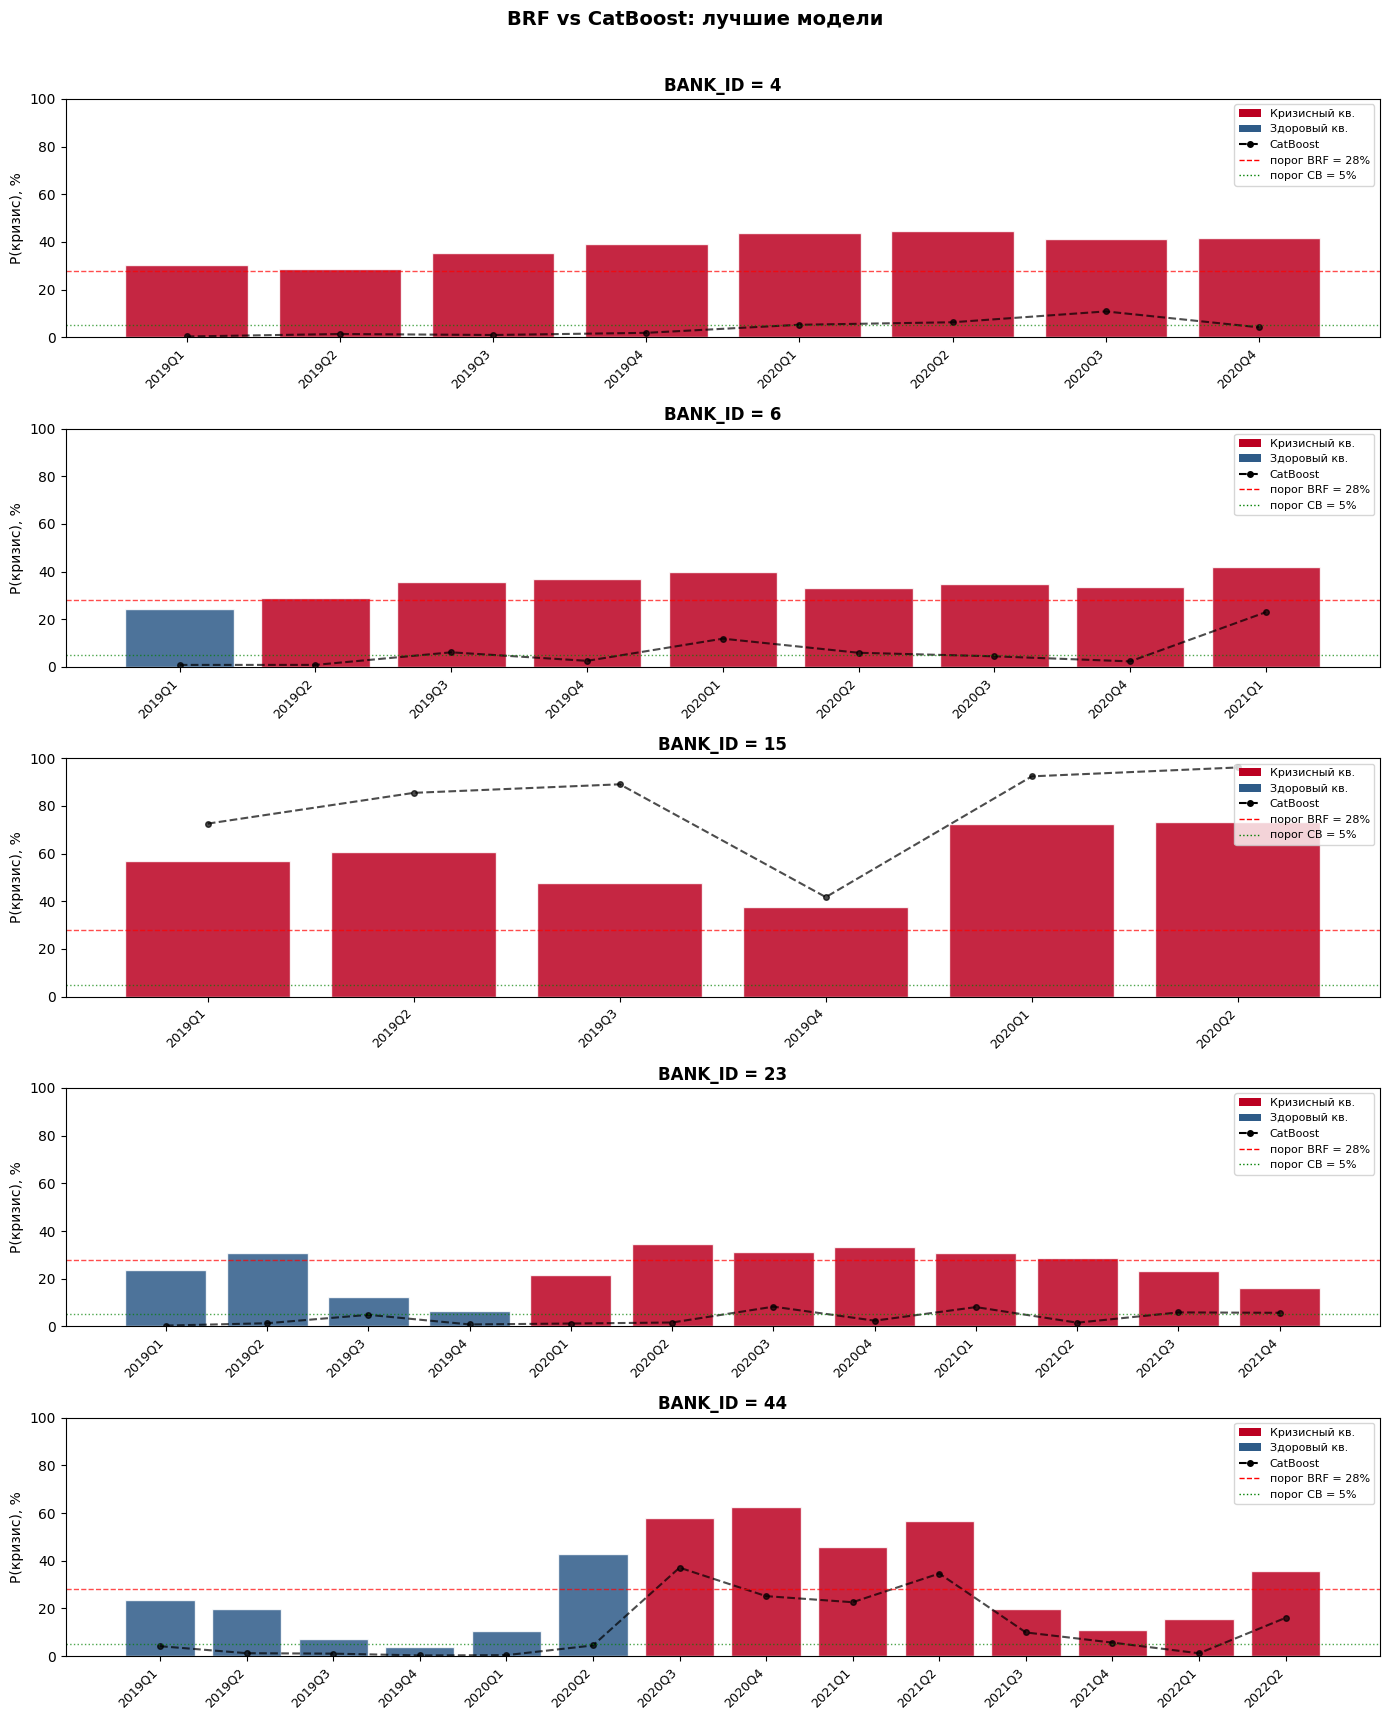

In [45]:
# Вероятности
prob_brf_best = brf_int.predict_proba(X_test_int)[:, 1]
prob_cb_best = cb_all.predict_proba(X_test_all)[:, 1]

# Пороги
thresh_brf = res_brf_int['Threshold']
thresh_cb = res_cb_all['Threshold']

print(f"BRF: порог={thresh_brf}, CB: порог={thresh_cb}")

# Собираем в один df
test_comp = test_int[['BANK_ID', 'Quarter', 'target_8q_window']].copy()
test_comp['prob_brf'] = prob_brf_best

test_cb_tmp = test_all[['BANK_ID', 'Quarter']].copy()
test_cb_tmp['prob_cb'] = prob_cb_best

test_comp = test_comp.merge(test_cb_tmp, on=['BANK_ID', 'Quarter'], how='inner')
print(f"Merged: {len(test_comp)}")

crisis_banks = sorted(test_comp[test_comp.target_8q_window == 1].BANK_ID.unique())

fig, axes = plt.subplots(len(crisis_banks), 1, figsize=(14, 3.5 * len(crisis_banks)))
if len(crisis_banks) == 1:
    axes = [axes]

for ax, bid in zip(axes, crisis_banks):
    bdata = test_comp[test_comp.BANK_ID == bid].sort_values('Quarter')
    quarters = bdata['Quarter'].dt.to_period('Q').astype(str)
    x = range(len(quarters))
    probs_brf = bdata['prob_brf'].values * 100
    probs_cb = bdata['prob_cb'].values * 100
    is_crisis = bdata['target_8q_window'].values

    bar_colors = ['#BB0021' if c == 1 else '#2E5B88' for c in is_crisis]
    
    # BRF — бары
    ax.bar(x, probs_brf, color=bar_colors, edgecolor='white', width=0.8, alpha=0.85)
    # CB — линия
    ax.plot(x, probs_cb, color='black', marker='o', markersize=4, linewidth=1.5,
            linestyle='--', alpha=0.7)
    
    # Оба порога
    ax.axhline(y=thresh_brf * 100, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.axhline(y=thresh_cb * 100, color='green', linestyle=':', linewidth=1, alpha=0.7)
    
    ax.set_xticks(x)
    ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('P(кризис), %')
    ax.set_ylim(0, 100)
    ax.set_title(f'BANK_ID = {bid}', fontweight='bold', fontsize=12)

    legend_items = [
        Patch(facecolor='#BB0021', label='Кризисный кв.'),
        Patch(facecolor='#2E5B88', label='Здоровый кв.'),
        Line2D([0], [0], color='black', linestyle='--', marker='o', markersize=4, label='CatBoost'),
        Line2D([0], [0], color='red', linestyle='--', linewidth=1, label=f'порог BRF = {thresh_brf*100:.0f}%'),
        Line2D([0], [0], color='green', linestyle=':', linewidth=1, label=f'порог CB = {thresh_cb*100:.0f}%'),
    ]
    ax.legend(handles=legend_items, fontsize=8, loc='upper right')

fig.suptitle('BRF vs CatBoost: лучшие модели',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig('best_models_crisis_banks.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [46]:
# # ====================================================
# # БРУТФОРС: поиск лучших interactions для BRF
# # ====================================================
# from itertools import combinations
# import time

# print("="*70)
# print("БРУТФОРС: поиск лучших interactions")
# print("="*70)

# # Все кандидаты для interactions
# candidates = top_features + ['d_NPL', 'ROE_excess']
# # Добавляем d_CAR если есть
# if 'd_CAR' not in df.columns:
#     df['d_CAR'] = df.groupby('BANK_ID')['Capital buffer (CAR)'].diff()
#     df['d_CAR'] = df['d_CAR'].fillna(0)
# candidates.append('d_CAR')

# print(f"Кандидатов: {len(candidates)}")
# print(f"Пар: {len(list(combinations(candidates, 2)))}")

# # Подготовка данных
# df_brute = df.copy()
# train_br = df_brute[df_brute.Quarter < split_date]
# test_br = df_brute[df_brute.Quarter >= split_date]

# # === ЭТАП 1: тестируем каждую пару по отдельности ===
# print("\n--- Этап 1: одиночные пары ---")
# pair_results = []
# all_pairs = list(combinations(candidates, 2))

# start = time.time()
# for i, (f1, f2) in enumerate(all_pairs):
#     col = f'{f1}_x_{f2}'
    
#     feats = top_features + [col]
    
#     X_tr = np.column_stack([train_br[top_features].values, 
#                             (train_br[f1] * train_br[f2]).values])
#     X_te = np.column_stack([test_br[top_features].values,
#                             (test_br[f1] * test_br[f2]).values])
    
#     brf_tmp = BalancedRandomForestClassifier(random_state=42, n_jobs=-1, **best_params)
#     brf_tmp.fit(X_tr, train_br['target_8q_window'].values)
#     res = evaluate(test_br['target_8q_window'].values, brf_tmp.predict_proba(X_te)[:, 1])
    
#     pair_results.append({
#         'pair': (f1, f2), 'col': col,
#         'AUC': res['AUC'], 'F2': res['F2'], 'Precision': res['Precision'],
#         'Recall': res['Recall'], 'FP': res['FP'], 'FN': res['FN'], 'TP': res['TP']
#     })
    
#     if (i+1) % 50 == 0:
#         elapsed = time.time() - start
#         print(f"  {i+1}/{len(all_pairs)} пар за {elapsed:.0f}с")

# pair_df = pd.DataFrame(pair_results).sort_values('F2', ascending=False)
# print(f"\nТоп-20 пар по F2:")
# print(pair_df.head(20)[['col', 'AUC', 'F2', 'Precision', 'Recall', 'FP', 'FN']].to_string(index=False))

# # === ЭТАП 2: комбинации из топ-15 пар (по 2-5 штук) ===
# print("\n--- Этап 2: комбинации топ-15 пар ---")
# top_pairs = pair_df.head(15)['pair'].tolist()

# combo_results = []
# start2 = time.time()
# total_combos = 0

# for n_pairs in range(2, 6):  # 2, 3, 4, 5 пар
#     combos = list(combinations(range(len(top_pairs)), n_pairs))
#     total_combos += len(combos)
    
#     for combo in combos:
#         selected = [top_pairs[j] for j in combo]
        
#         # Строим фичи
#         int_vals_tr = []
#         int_vals_te = []
#         int_names = []
#         for f1, f2 in selected:
#             int_vals_tr.append((train_br[f1] * train_br[f2]).values)
#             int_vals_te.append((test_br[f1] * test_br[f2]).values)
#             int_names.append(f'{f1}_x_{f2}')
        
#         X_tr = np.column_stack([train_br[top_features].values] + int_vals_tr)
#         X_te = np.column_stack([test_br[top_features].values] + int_vals_te)
        
#         brf_tmp = BalancedRandomForestClassifier(random_state=42, n_jobs=-1, **best_params)
#         brf_tmp.fit(X_tr, train_br['target_8q_window'].values)
#         res = evaluate(test_br['target_8q_window'].values, brf_tmp.predict_proba(X_te)[:, 1])
        
#         combo_results.append({
#             'pairs': int_names, 'n_pairs': n_pairs,
#             'AUC': res['AUC'], 'F2': res['F2'], 'Precision': res['Precision'],
#             'Recall': res['Recall'], 'FP': res['FP'], 'FN': res['FN'], 'TP': res['TP']
#         })

# elapsed2 = time.time() - start2
# print(f"  {total_combos} комбинаций за {elapsed2:.0f}с")

# combo_df = pd.DataFrame(combo_results).sort_values('F2', ascending=False)
# print(f"\nТоп-20 комбинаций по F2:")
# for _, row in combo_df.head(20).iterrows():
#     print(f"  F2={row['F2']:.3f} AUC={row['AUC']:.3f} Prec={row['Precision']:.3f} "
#           f"Rec={row['Recall']:.3f} FP={row['FP']} FN={row['FN']} | {row['pairs']}")

# # === Лучший результат ===
# best = combo_df.iloc[0]
# print(f"\n{'='*70}")
# print(f"ЛУЧШИЙ РЕЗУЛЬТАТ:")
# print(f"  F2={best['F2']:.3f} AUC={best['AUC']:.3f} Prec={best['Precision']:.3f} Rec={best['Recall']:.3f}")
# print(f"  FP={best['FP']} FN={best['FN']} TP={best['TP']}")
# print(f"  Interactions: {best['pairs']}")
# print(f"{'='*70}")

In [47]:
# # === Шаг 6: Усреднение ===
# # Определяем лучший BRF и лучший CB по F2 — подставь правильные после прогона
# print("\n" + "="*70)
# print("Шаг 6: Усреднение лучшего BRF и лучшего CB")
# print("="*70)

# # Используем BRF+int и CB+SMOTE+int (на одинаковом тесте)
# prob_brf_best = brf_int.predict_proba(X_test_int)[:, 1]
# prob_cb_best = cb_smote_int.predict_proba(X_test_int)[:, 1]

# for w in [0.3, 0.4, 0.5, 0.6, 0.7]:
#     prob_avg = w * prob_brf_best + (1 - w) * prob_cb_best
#     res = evaluate(test_int['target_8q_window'].values, prob_avg)
#     print(f"  w_BRF={w:.1f}  AUC={res['AUC']} F2={res['F2']} Prec={res['Precision']} "
#           f"Rec={res['Recall']} FP={res['FP']} FN={res['FN']} TP={res['TP']}")

In [48]:
# # === Шаг 7: Стэкинг ===
# print("\n" + "="*70)
# print("Шаг 7: Стэкинг (TimeSeriesSplit)")
# print("="*70)

# y_train_int = train_int['target_8q_window'].values

# oof_brf = np.zeros(len(X_train_int))
# oof_cb = np.zeros(len(X_train_int))
# test_brf_stack = np.zeros(len(X_test_int))
# test_cb_stack = np.zeros(len(X_test_int))

# tscv_stack = TimeSeriesSplit(n_splits=3)

# for tr_idx, val_idx in tscv_stack.split(X_train_int):
#     brf_s = BalancedRandomForestClassifier(random_state=42, n_jobs=-1, **best_params)
#     brf_s.fit(X_train_int[tr_idx], y_train_int[tr_idx])
#     oof_brf[val_idx] = brf_s.predict_proba(X_train_int[val_idx])[:, 1]
#     test_brf_stack += brf_s.predict_proba(X_test_int)[:, 1] / 3

#     X_sm_s, y_sm_s = SMOTE(random_state=42).fit_resample(X_train_int[tr_idx], y_train_int[tr_idx])
#     cb_s = CatBoostClassifier(random_seed=42, verbose=0, monotone_constraints=mono_int_no_spw,
#                                iterations=300, depth=6, learning_rate=0.05)
#     cb_s.fit(X_sm_s, y_sm_s)
#     oof_cb[val_idx] = cb_s.predict_proba(X_train_int[val_idx])[:, 1]
#     test_cb_stack += cb_s.predict_proba(X_test_int)[:, 1] / 3

# meta_X_train = np.column_stack([oof_brf, oof_cb])
# meta_X_test = np.column_stack([test_brf_stack, test_cb_stack])

# meta = LogisticRegression(class_weight='balanced', random_state=42)
# meta.fit(meta_X_train, y_train_int)
# prob_stack = meta.predict_proba(meta_X_test)[:, 1]

# res_stack = evaluate(test_int['target_8q_window'].values, prob_stack)
# print(f"  Stacking: AUC={res_stack['AUC']} F2={res_stack['F2']} Prec={res_stack['Precision']} "
#       f"Rec={res_stack['Recall']} FP={res_stack['FP']} FN={res_stack['FN']} TP={res_stack['TP']}")

In [49]:
# # === Шаг 8: AND/OR правила ===
# print("\n" + "="*70)
# print("Шаг 8: AND/OR правила")
# print("="*70)

# prob_brf_final = brf_int.predict_proba(X_test_int)[:, 1]
# prob_cb_final = cb_smote_int.predict_proba(X_test_int)[:, 1]
# y_test_final = test_int['target_8q_window'].values

# rules = [
#     ('BRF>0.19 (standalone)',  (prob_brf_final >= 0.19)),
#     ('BRF>0.19 OR CB>0.05',   (prob_brf_final >= 0.19) | (prob_cb_final >= 0.05)),
#     ('BRF>0.19 AND CB>0.03',  (prob_brf_final >= 0.19) & (prob_cb_final >= 0.03)),
#     ('BRF>0.19 AND CB>0.05',  (prob_brf_final >= 0.19) & (prob_cb_final >= 0.05)),
#     ('BRF>0.2 AND CB>0.1',    (prob_brf_final >= 0.2)  & (prob_cb_final >= 0.1)),
# ]

# print(f"{'Правило':<30} {'Prec':>6} {'Rec':>6} {'F2':>6} {'FP':>5} {'FN':>5} {'TP':>5}")
# for name, pred in rules:
#     pred = pred.astype(int)
#     tp = ((pred == 1) & (y_test_final == 1)).sum()
#     fp = ((pred == 1) & (y_test_final == 0)).sum()
#     fn = ((pred == 0) & (y_test_final == 1)).sum()
#     rec = tp / (tp + fn) if (tp + fn) > 0 else 0
#     prec = tp / (tp + fp) if (tp + fp) > 0 else 0
#     f2 = (5 * prec * rec) / (4 * prec + rec) if (4 * prec + rec) > 0 else 0
#     print(f"  {name:<28} {prec:>6.3f} {rec:>6.3f} {f2:>6.3f} {fp:>5} {fn:>5} {tp:>5}")

## 3.4) SHAP

In [50]:
import shap

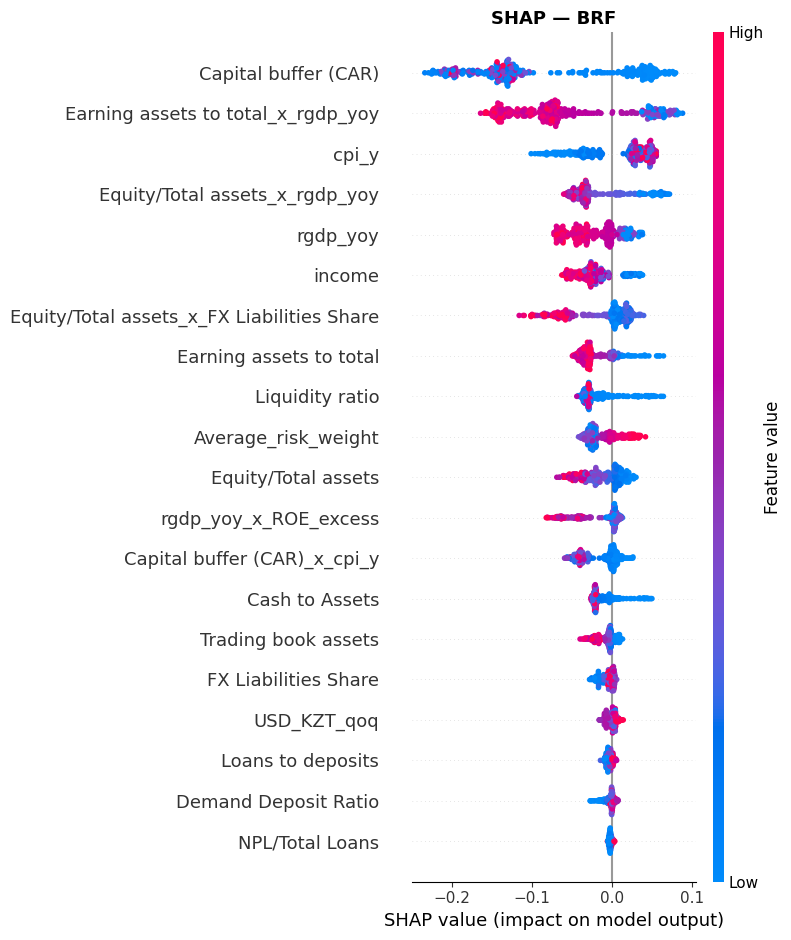

In [51]:
explainer_brf = shap.TreeExplainer(brf_int)
shap_values_brf = explainer_brf.shap_values(X_test_int, check_additivity=False)

if isinstance(shap_values_brf, list):
    shap_vals_brf = shap_values_brf[1]
elif np.array(shap_values_brf).ndim == 3:
    shap_vals_brf = np.array(shap_values_brf)[:, :, 1]
else:
    shap_vals_brf = shap_values_brf

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_brf, X_test_int,
                  feature_names=features_with_int, show=False, max_display=20)
plt.title('SHAP — BRF', fontweight='bold', fontsize=13)
plt.tight_layout()
# plt.savefig('shap_brf_best.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

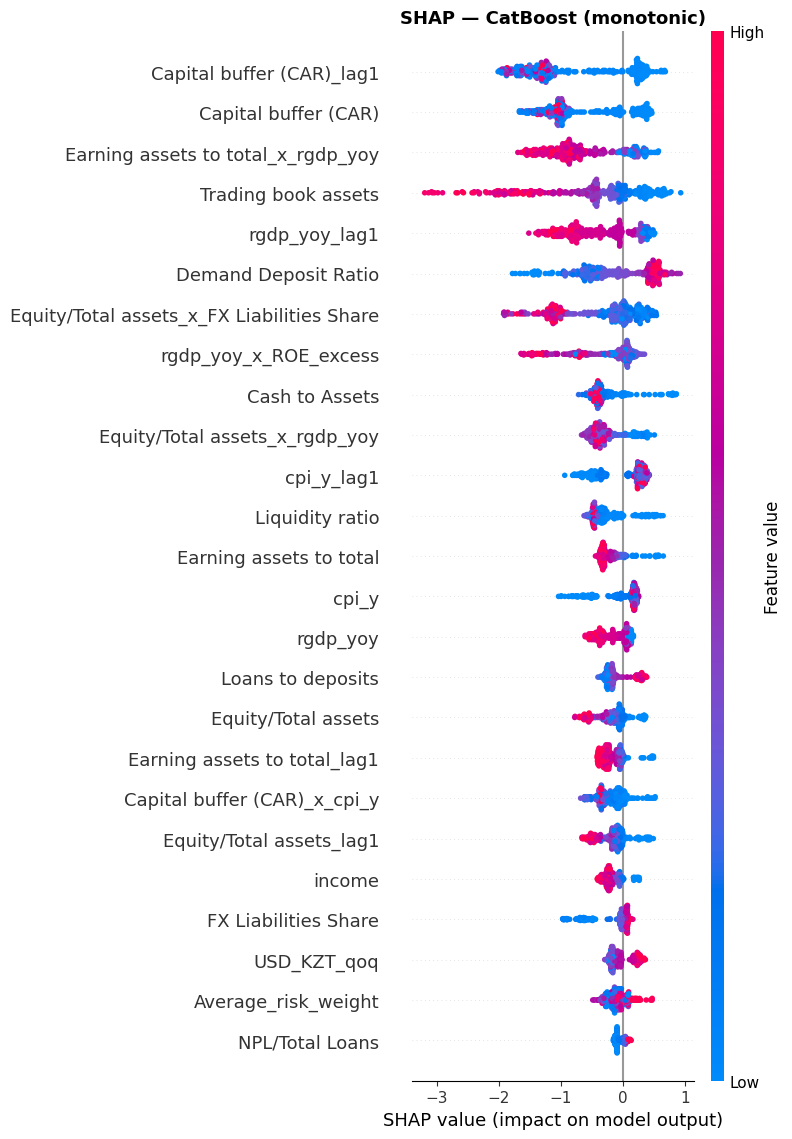

In [52]:
explainer_cb = shap.TreeExplainer(cb_all)
shap_values_cb = explainer_cb.shap_values(X_test_all)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_cb, X_test_all,
                  feature_names=features_all, show=False, max_display=25)
plt.title('SHAP — CatBoost (monotonic)', fontweight='bold', fontsize=13)
plt.tight_layout()
# plt.savefig('shap_cb_best.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


In [53]:
print("\n=== Топ-10 SHAP (BRF) ===")
mean_brf = np.abs(shap_vals_brf).mean(axis=0)
for idx in np.argsort(mean_brf)[::-1][:10]:
    print(f"  {features_with_int[idx]:45} {mean_brf[idx]:.4f}")

print("\n=== Топ-10 SHAP (CatBoost) ===")
mean_cb = np.abs(shap_values_cb).mean(axis=0)
for idx in np.argsort(mean_cb)[::-1][:10]:
    print(f"  {features_all[idx]:45} {mean_cb[idx]:.4f}")


=== Топ-10 SHAP (BRF) ===
  Capital buffer (CAR)                          0.1104
  Earning assets to total_x_rgdp_yoy            0.0833
  cpi_y                                         0.0389
  Equity/Total assets_x_rgdp_yoy                0.0380
  rgdp_yoy                                      0.0300
  income                                        0.0289
  Equity/Total assets_x_FX Liabilities Share    0.0279
  Earning assets to total                       0.0278
  Liquidity ratio                               0.0263
  Average_risk_weight                           0.0205

=== Топ-10 SHAP (CatBoost) ===
  Capital buffer (CAR)_lag1                     0.9854
  Capital buffer (CAR)                          0.7901
  Earning assets to total_x_rgdp_yoy            0.7787
  Trading book assets                           0.7314
  rgdp_yoy_lag1                                 0.5699
  Demand Deposit Ratio                          0.5280
  Equity/Total assets_x_FX Liabilities Share    0.5159
  rgdp

In [54]:
# Полный ранг SHAP — обе модели
print("=== Все SHAP (BRF) ===")
mean_brf = np.abs(shap_vals_brf).mean(axis=0)
brf_rank = pd.DataFrame({'feature': features_with_int, 'mean_shap': mean_brf})
brf_rank = brf_rank.sort_values('mean_shap', ascending=False).reset_index(drop=True)
brf_rank.index += 1
print(brf_rank.round(4).to_string())

print("\n=== Все SHAP (CatBoost) ===")
mean_cb = np.abs(shap_values_cb).mean(axis=0)
cb_rank = pd.DataFrame({'feature': features_all, 'mean_shap': mean_cb})
cb_rank = cb_rank.sort_values('mean_shap', ascending=False).reset_index(drop=True)
cb_rank.index += 1
print(cb_rank.round(4).to_string())

# Пересечение топ-10
top_brf = set(brf_rank.head(10)['feature'])
top_cb = set(cb_rank.head(10)['feature'])
print(f"\nСовпадают в топ-10: {top_brf & top_cb}")
print(f"Только BRF: {top_brf - top_cb}")
print(f"Только CatBoost: {top_cb - top_brf}")

=== Все SHAP (BRF) ===
                                       feature  mean_shap
1                         Capital buffer (CAR)     0.1104
2           Earning assets to total_x_rgdp_yoy     0.0833
3                                        cpi_y     0.0389
4               Equity/Total assets_x_rgdp_yoy     0.0380
5                                     rgdp_yoy     0.0300
6                                       income     0.0289
7   Equity/Total assets_x_FX Liabilities Share     0.0279
8                      Earning assets to total     0.0278
9                              Liquidity ratio     0.0263
10                         Average_risk_weight     0.0205
11                         Equity/Total assets     0.0202
12                       rgdp_yoy_x_ROE_excess     0.0193
13                Capital buffer (CAR)_x_cpi_y     0.0191
14                              Cash to Assets     0.0172
15                         Trading book assets     0.0092
16                        FX Liabilities Share   

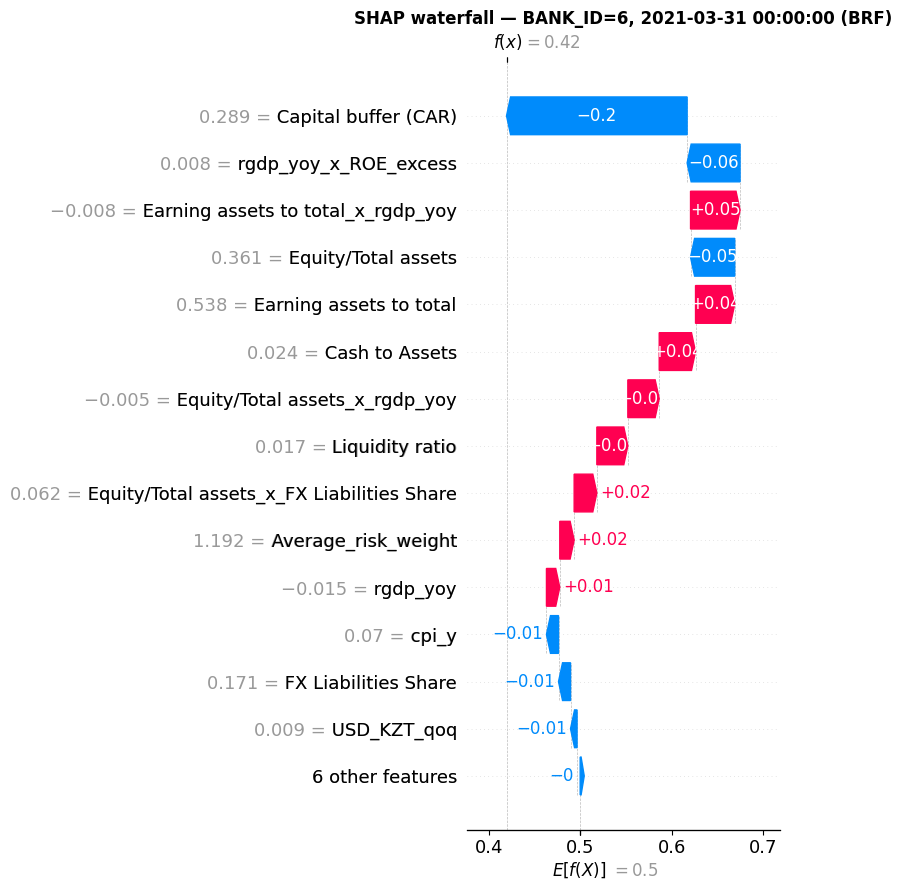

In [55]:
bank_id = 6

# === BRF ===
idx_brf = test_int[test_int.BANK_ID == bank_id].index[-1]
pos_brf = list(test_int.index).index(idx_brf)
q_brf = test_int.loc[idx_brf, 'Quarter']

bv_brf = explainer_brf.expected_value
if isinstance(bv_brf, (list, np.ndarray)):
    bv_brf = float(bv_brf[1])
else:
    bv_brf = float(bv_brf)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_vals_brf[pos_brf],
    base_values=bv_brf,
    data=X_test_int[pos_brf],
    feature_names=features_with_int
), max_display=15, show=False)
plt.title(f'SHAP waterfall — BANK_ID={bank_id}, {q_brf} (BRF)', fontweight='bold')
plt.tight_layout()
# plt.savefig(f'shap_waterfall_brf_{bank_id}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

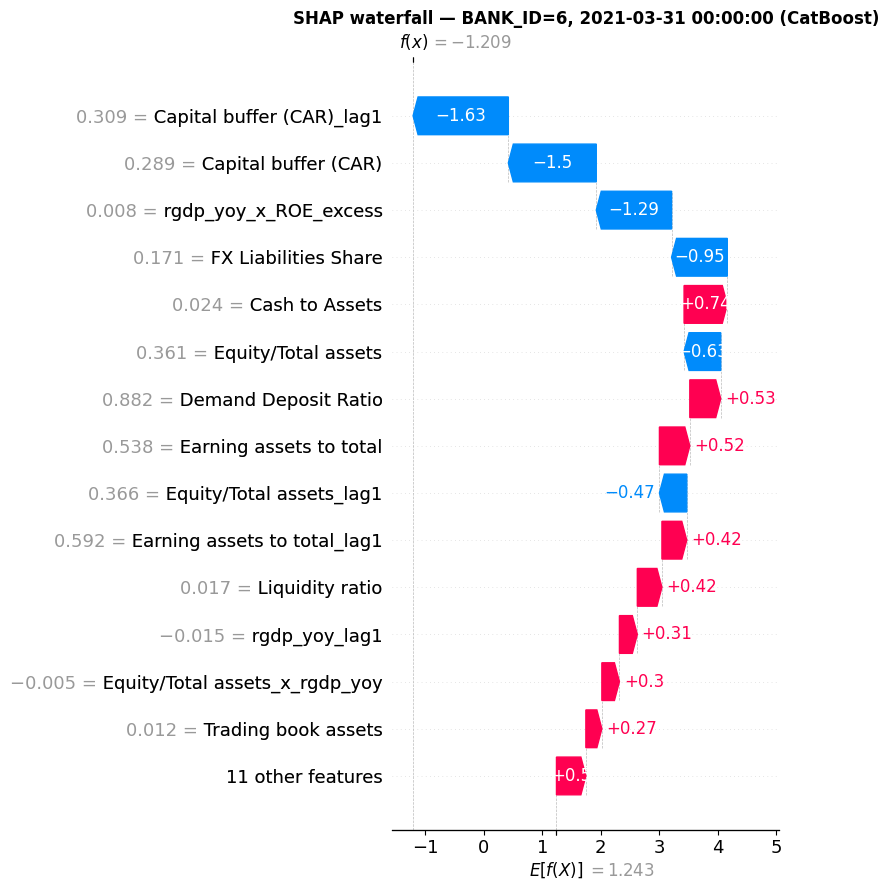

In [56]:

# === CatBoost ===
idx_cb = test_all[test_all.BANK_ID == bank_id].index[-1]
pos_cb = list(test_all.index).index(idx_cb)
q_cb = test_all.loc[idx_cb, 'Quarter']

bv_cb = explainer_cb.expected_value
if isinstance(bv_cb, (list, np.ndarray)):
    bv_cb = float(bv_cb[1])
else:
    bv_cb = float(bv_cb)

plt.figure(figsize=(10, 8))
shap.waterfall_plot(shap.Explanation(
    values=shap_values_cb[pos_cb],
    base_values=bv_cb,
    data=X_test_all[pos_cb],
    feature_names=features_all
), max_display=15, show=False)
plt.title(f'SHAP waterfall — BANK_ID={bank_id}, {q_cb} (CatBoost)', fontweight='bold')
plt.tight_layout()
# plt.savefig(f'shap_waterfall_cb_{bank_id}.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# 3.5) 2 level system

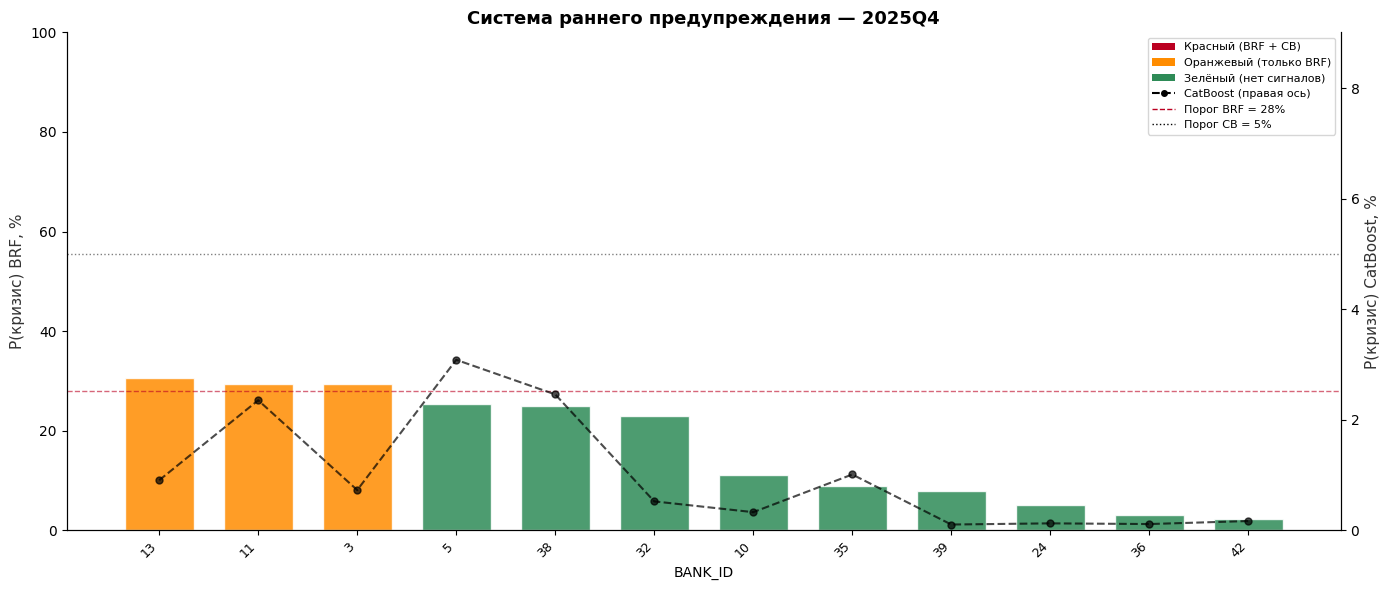


Светофор на 2025Q4:
  Красных:   0
  Оранжевых: 3
  Зелёных:   9
    BANK_ID= 13  BRF=30.6%  CB=0.9%  → Оранжевый
    BANK_ID= 11  BRF=29.3%  CB=2.4%  → Оранжевый
    BANK_ID=  3  BRF=29.3%  CB=0.7%  → Оранжевый
    BANK_ID=  5  BRF=25.3%  CB=3.1%  → Зелёный
    BANK_ID= 38  BRF=25.0%  CB=2.5%  → Зелёный
    BANK_ID= 32  BRF=22.9%  CB=0.5%  → Зелёный
    BANK_ID= 10  BRF=11.1%  CB=0.3%  → Зелёный
    BANK_ID= 35  BRF=8.9%  CB=1.0%  → Зелёный
    BANK_ID= 39  BRF=7.9%  CB=0.1%  → Зелёный
    BANK_ID= 24  BRF=5.0%  CB=0.1%  → Зелёный
    BANK_ID= 36  BRF=3.0%  CB=0.1%  → Зелёный
    BANK_ID= 42  BRF=2.2%  CB=0.2%  → Зелёный


In [57]:
# Светофор — двухосевой график
last_q = test_int['Quarter'].max()

last_brf = test_int[test_int.Quarter == last_q].copy()
last_cb = test_all[test_all.Quarter == last_q].copy()

last_brf['prob_brf'] = brf_int.predict_proba(
    last_brf[features_with_int].values)[:, 1]
last_cb['prob_cb'] = cb_all.predict_proba(
    last_cb[features_all].values)[:, 1]

traffic = last_brf[['BANK_ID', 'Quarter', 'target_8q_window', 'prob_brf']].merge(
    last_cb[['BANK_ID', 'Quarter', 'prob_cb']], on=['BANK_ID', 'Quarter'])

def traffic_light(row):
    if row['prob_brf'] < 0.28:
        return 'Зелёный'
    elif row['prob_cb'] < 0.05:
        return 'Оранжевый'
    else:
        return 'Красный'

traffic['signal'] = traffic.apply(traffic_light, axis=1)
traffic = traffic.sort_values('prob_brf', ascending=False).reset_index(drop=True)

# Цвета
color_map = {'Красный': '#BB0021', 'Оранжевый': '#FF8C00', 'Зелёный': '#2E8B57'}
bar_colors = [color_map[s] for s in traffic['signal']]

# Метки по x
labels = [f"{int(b)}{'★' if t == 1 else ''}" 
          for b, t in zip(traffic['BANK_ID'], traffic['target_8q_window'])]

fig, ax1 = plt.subplots(figsize=(14, 6))
x = range(len(traffic))

# BRF — столбики
ax1.bar(x, traffic['prob_brf'].values * 100, color=bar_colors, 
        width=0.7, alpha=0.85, edgecolor='white', label='BRF')
ax1.axhline(y=28, color='#BB0021', linestyle='--', linewidth=1, alpha=0.6, label='Порог BRF = 28%')
ax1.set_ylabel('P(кризис) BRF, %', fontsize=11, color='#333333')
ax1.set_ylim(0, 100)

# CatBoost — линия на второй оси
ax2 = ax1.twinx()
ax2.plot(x, traffic['prob_cb'].values * 100, color='black', marker='o', 
         markersize=5, linewidth=1.5, linestyle='--', alpha=0.7, label='CatBoost')
ax2.axhline(y=5, color='black', linestyle=':', linewidth=1, alpha=0.5, label='Порог CB = 5%')
ax2.set_ylabel('P(кризис) CatBoost, %', fontsize=11, color='#333333')
ax2.set_ylim(0, max(traffic['prob_cb'].values * 100) * 1.3 + 5)

# X ось
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax1.set_xlabel('BANK_ID', fontsize=10)

# Легенда
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_items = [
    Patch(facecolor='#BB0021', label='Красный (BRF + CB)'),
    Patch(facecolor='#FF8C00', label='Оранжевый (только BRF)'),
    Patch(facecolor='#2E8B57', label='Зелёный (нет сигналов)'),
    Line2D([0], [0], color='black', linestyle='--', marker='o', markersize=4, label='CatBoost (правая ось)'),
    Line2D([0], [0], color='#BB0021', linestyle='--', linewidth=1, label='Порог BRF = 28%'),
    Line2D([0], [0], color='black', linestyle=':', linewidth=1, label='Порог CB = 5%'),
]
ax1.legend(handles=legend_items, fontsize=8, loc='upper right')

q_str = pd.Timestamp(last_q).to_period('Q')
ax1.set_title(f'Система раннего предупреждения — {q_str}',
              fontsize=13, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
# plt.savefig('traffic_light.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

# Статистика
print(f"\nСветофор на {q_str}:")
print(f"  Красных:   {(traffic.signal == 'Красный').sum()}")
print(f"  Оранжевых: {(traffic.signal == 'Оранжевый').sum()}")
print(f"  Зелёных:   {(traffic.signal == 'Зелёный').sum()}")
for _, row in traffic.iterrows():
    star = '★' if row['target_8q_window'] == 1 else ' '
    print(f"  {star} BANK_ID={int(row['BANK_ID']):3}  BRF={row['prob_brf']:.1%}  CB={row['prob_cb']:.1%}  → {row['signal']}")

In [65]:
import pickle

with open('brf_int_model.pkl', 'wb') as f:
    pickle.dump({'model': brf_int, 'features': features_with_int}, f)

with open('cb_all_model.pkl', 'wb') as f:
    pickle.dump({'model': cb_all, 'features': features_all}, f)

print("Сохранено с фичами")

Сохранено с фичами


In [59]:

# # === Сохраняем модели ===


# # === Витрина 1: traffic_light ===
# # (можно на любых данных, здесь пример на тесте)

# traffic_df = test_int[['BANK_ID', 'Quarter', 'target_8q_window']].copy()
# traffic_df['prob_brf'] = brf_int.predict_proba(X_test_int)[:, 1]

# cb_probs = cb_all.predict_proba(X_test_all)[:, 1]
# cb_tmp = test_all[['BANK_ID', 'Quarter']].copy()
# cb_tmp['prob_cb'] = cb_probs
# traffic_df = traffic_df.merge(cb_tmp, on=['BANK_ID', 'Quarter'])

# def get_signal(row):
#     if row['prob_brf'] < 0.28:
#         return 'green'
#     elif row['prob_cb'] < 0.05:
#         return 'orange'
#     else:
#         return 'red'

# traffic_df['signal'] = traffic_df.apply(get_signal, axis=1)
# traffic_df.to_csv('vitrina_traffic_light.csv', index=False)
# print(f"traffic_light: {len(traffic_df)} строк")

# # === Витрина 2: shap_details ===

# # BRF SHAP
# explainer_brf = shap.TreeExplainer(brf_int)
# shap_brf = explainer_brf.shap_values(X_test_int, check_additivity=False)
# if isinstance(shap_brf, list):
#     shap_brf = shap_brf[1]
# elif np.array(shap_brf).ndim == 3:
#     shap_brf = np.array(shap_brf)[:, :, 1]

# # CatBoost SHAP
# explainer_cb = shap.TreeExplainer(cb_all)
# shap_cb = explainer_cb.shap_values(X_test_all)

# # Собираем в длинный формат
# rows = []

# for i in range(len(test_int)):
#     bid = test_int.iloc[i]['BANK_ID']
#     q = test_int.iloc[i]['Quarter']
#     for j, feat in enumerate(features_with_int):
#         rows.append({
#             'BANK_ID': int(bid), 'Quarter': q, 'model': 'BRF',
#             'feature': feat,
#             'shap_value': round(float(shap_brf[i, j]), 6),
#             'feature_value': round(float(X_test_int[i, j]), 6),
#             'feature_rank': 0  # заполним ниже
#         })

# for i in range(len(test_all)):
#     bid = test_all.iloc[i]['BANK_ID']
#     q = test_all.iloc[i]['Quarter']
#     for j, feat in enumerate(features_all):
#         rows.append({
#             'BANK_ID': int(bid), 'Quarter': q, 'model': 'CatBoost',
#             'feature': feat,
#             'shap_value': round(float(shap_cb[i, j]), 6),
#             'feature_value': round(float(X_test_all[i, j]), 6),
#             'feature_rank': 0
#         })

# shap_df = pd.DataFrame(rows)

# # Ранг внутри каждого банк-квартал-модель
# shap_df['abs_shap'] = shap_df['shap_value'].abs()
# shap_df['feature_rank'] = shap_df.groupby(['BANK_ID', 'Quarter', 'model'])['abs_shap'].rank(ascending=False).astype(int)
# shap_df = shap_df.drop('abs_shap', axis=1)

# shap_df.to_csv('vitrina_shap_details.csv', index=False)
# print(f"shap_details: {len(shap_df)} строк")

In [60]:
# import vertica_python

# # Подключение
# conn_info = {
#     'host': 'твой_хост',
#     'port': 5433,
#     'user': 'твой_юзер',
#     'password': 'твой_пароль',
#     'database': 'твоя_бд',
# }

# conn = vertica_python.connect(**conn_info)
# cur = conn.cursor()

# # === Создаём таблицы (один раз) ===

# cur.execute("""
#     CREATE TABLE IF NOT EXISTS ews.traffic_light (
#         bank_id INT,
#         quarter DATE,
#         prob_brf FLOAT,
#         prob_cb FLOAT,
#         signal VARCHAR(10),
#         target_8q_window INT
#     )
# """)

# cur.execute("""
#     CREATE TABLE IF NOT EXISTS ews.shap_details (
#         bank_id INT,
#         quarter DATE,
#         model VARCHAR(20),
#         feature VARCHAR(100),
#         shap_value FLOAT,
#         feature_value FLOAT,
#         feature_rank INT
#     )
# """)

# conn.commit()

# # === Загрузка traffic_light ===

# # Очищаем перед загрузкой (или DELETE WHERE quarter = ...)
# cur.execute("TRUNCATE TABLE ews.traffic_light")

# for _, row in traffic_df.iterrows():
#     cur.execute("""
#         INSERT INTO ews.traffic_light 
#         (bank_id, quarter, prob_brf, prob_cb, signal, target_8q_window)
#         VALUES (%s, %s, %s, %s, %s, %s)
#     """, (int(row['BANK_ID']), row['Quarter'], 
#           float(row['prob_brf']), float(row['prob_cb']),
#           row['signal'], int(row['target_8q_window'])))

# conn.commit()
# print(f"traffic_light: {len(traffic_df)} строк загружено")

# # === Загрузка shap_details (быстрее через COPY) ===

# # Вариант 1: через COPY из CSV (быстро, рекомендуется для больших таблиц)
# shap_df.to_csv('/tmp/shap_details.csv', index=False)
# cur.execute("""
#     COPY ews.shap_details FROM LOCAL '/tmp/shap_details.csv'
#     DELIMITER ',' ENCLOSED BY '"' SKIP 1 ABORT ON ERROR
# """)
# conn.commit()
# print(f"shap_details: {len(shap_df)} строк загружено через COPY")

# # Вариант 2: через INSERT (медленнее, но проще)
# # for _, row in shap_df.iterrows():
# #     cur.execute("""
# #         INSERT INTO ews.shap_details VALUES (%s,%s,%s,%s,%s,%s,%s)
# #     """, (int(row['BANK_ID']), row['Quarter'], row['model'],
# #           row['feature'], float(row['shap_value']),
# #           float(row['feature_value']), int(row['feature_rank'])))

# cur.close()
# conn.close()